# Missing values and imputation


## Missing values

**Source of missing values:**

* Data Extraction: It is possible that there are problems with extraction process. In such cases, we should double-check for correct data with data guardians. Some hashing procedures can also be used to make sure that data extraction is correct. Errors at data extraction stage are typically easy to find and can be corrected easily as well.
* Data collection: These errors occur at time of data collection and are harder to correct. They can be categorized in four types:
>* Missing completely at random: This is a case when the probability of missing variable is same for all observations. For example: respondents of data collection process decide that they will declare their earning after tossing a fair coin. If an head occurs, respondent declares his / her earnings & vice versa. Here each observation has equal chance of missing value.
>* Missing at random: This is a case when variable is missing at random and missing ratio varies for different values / level of other input variables. For example: We are collecting data for age and female has higher missing value compare to male.
>* Missing that depends on unobserved predictors: This is a case when the missing values are not random and are related to the unobserved input variable. For example: In a medical study, if a particular diagnostic causes discomfort, then there is higher chance of drop out from the study. This missing value is not at random unless we have included “discomfort” as an input variable for all patients.
>* Missing that depends on the missing value itself: This is a case when the probability of missing value is directly correlated with missing value itself. For example: People with higher or lower income are likely to provide non-response to their earning.

We are going to use the Titanic dataset again in this tutorial to explore missing data.

## 为什么会有缺失值？  

在数据里，有些地方就是空的（比如年龄没填、收入没报），这就是缺失值。它们产生的原因主要有两大类：  

1. **在抽数据的时候出错了**  
   - 比如导出数据时少了一列、字段对不上。  
   - 这种问题通常容易发现，和数据管理员确认一下就能修好。  

2. **在收集数据的时候出错了**  
   - 这类情况更复杂，因为是人没填，或者条件导致数据根本没收上来。  
   - 常见的 4 种情况：  

---

### 四种缺失的类型  

1. **完全随机缺失 (MCAR)**  
   - 就是“谁缺都一样”。  
   - 比如问卷里：受访者抛硬币，正面就填收入，反面就不填。这样每个人缺的概率一样。  

2. **随机缺失 (MAR)**  
   - 缺不缺，取决于别的已知信息。  
   - 比如：我们统计年龄，发现女生更容易不写年龄，男生大多会写。这里缺失情况和“性别”有关。  

3. **依赖于没观测到的东西 (NMAR / MNAR)**  
   - 缺失其实和某个我们没记录下来的因素有关。  
   - 比如：一个医学实验，检查过程很不舒服。结果耐不住的人退组了，我们没收上他们的数据。要是我们没有把“不舒服程度”这个信息记下来，就没法解释缺失为什么发生。  

4. **依赖于值本身的缺失**  
   - 缺不缺，取决于这个值本身。  
   - 比如：高收入或者低收入的人，更可能选择不报收入。缺失和“真实收入”直接相关。  

---

✨ 小结：  
- 如果缺失是随机的（情况 1、2），我们还能想办法补数据。  
- 如果缺失和数据本身相关（情况 3、4），那问题就比较严重，填补时需要特别小心。  


In [1]:
#import library 
import pandas as pd
import numpy as np

In [2]:
#load the data 
df1 = pd.read_csv('titanic passenger list.csv') 

We would normally check some data basics before analysis, such as 
* length (rows)
* width (or columns)
* column types
* basic stats
* head & tail of data

We will skip this step in this tutorial.

## Task 1 Check missing values 


`info()`
* tells us total number of records
* gives us details on datatype, 'object' here means string, the others are int and float
* also include see 'non-null' observations for each data column

`describe()` by default tabulates numeric data, which report on:
* descriptive statistics 
* number of non-null observations in "count"
* with "include='all'" will include all columns and "include=['O']" will include objects

`.isnull().sum()`
* will return sum of missing values for each column



In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [4]:
df1.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [5]:
df1.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [6]:
df1.size

18326

In [7]:
df1.shape

(1309, 14)

There are 1309 x 14 records and there are many missing values in "age","fare" (one record) "cabin", "boat" "body" and "home.dest".


#### Which of these are potentially imputatable i.e. we can derive values from existing data?


## Task 2 investigate with missing values for ages

Titanic data is commonly used for predictive analytics, e.g. remove the 'survived' column and feed the other data into an algorithm to see if there are any predictors for survival, pclass was a factor, also gender, age another (and if you ever go on a cruise ship change your name to "Womenandchildren").

Age are mostly missing. Should we just delete or do something basic like:  

meanAge = np.mean(df1.age)

df1.age = df1.age.fillna(meanAge) 

### Discussion:

* **What's wrong with this approach?**

* **What is the average age anyway?**

*  **What is the average age for males, for females? Is that an improvement?**


In [8]:
# 计算年龄的平均值
# 首先查看年龄的基本统计信息
print("年龄的基本统计信息：")
print(df1['age'].describe())

print("\n年龄的平均值：")
meanAge = df1['age'].mean()
print(f"平均年龄: {meanAge:.2f} 岁")

# 查看有多少缺失值
print(f"\n年龄缺失值数量: {df1['age'].isnull().sum()}")
print(f"总记录数: {len(df1)}")
print(f"缺失值比例: {df1['age'].isnull().sum()/len(df1)*100:.1f}%")

年龄的基本统计信息：
count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

年龄的平均值：
平均年龄: 29.88 岁

年龄缺失值数量: 263
总记录数: 1309
缺失值比例: 20.1%


In [9]:
# age - we know there are some missing, let's dig deeper
# 更深入地探索年龄数据

# 查看年龄的值计数（前20个最常见的年龄）
print("最常见的年龄值（前20个）:")
print(df1['age'].value_counts().head(20))

print("\n按性别分组的年龄统计:")
# 按性别分组查看年龄统计
gender_age_stats = df1.groupby('sex')['age'].describe()
print(gender_age_stats)

print("\n按性别分组的缺失值统计:")
# 查看不同性别的年龄缺失情况
missing_by_gender = df1.groupby('sex')['age'].apply(lambda x: x.isnull().sum())
total_by_gender = df1.groupby('sex').size()
missing_percent_by_gender = (missing_by_gender / total_by_gender * 100).round(2)

for gender in df1['sex'].unique():
    if pd.notna(gender):  # 确保性别不是NaN
        print(f"{gender}: {missing_by_gender[gender]}个缺失值 ({missing_percent_by_gender[gender]}%)")

最常见的年龄值（前20个）:
age
24.0    47
22.0    43
21.0    41
30.0    40
18.0    39
25.0    34
28.0    32
36.0    31
26.0    30
29.0    30
27.0    30
19.0    29
23.0    26
32.0    24
31.0    23
20.0    23
35.0    23
33.0    21
45.0    21
17.0    20
Name: count, dtype: int64

按性别分组的年龄统计:
        count       mean        std   min   25%   50%   75%   max
sex                                                              
female  388.0  28.687088  14.576962  0.17  19.0  27.0  38.0  76.0
male    658.0  30.585228  14.280581  0.33  21.0  28.0  39.0  80.0

按性别分组的缺失值统计:
female: 78个缺失值 (16.74%)
male: 185个缺失值 (21.95%)


In [10]:
# mostly younger, 20s to 30s
# 分析年龄分布，大部分乘客年龄在20-30岁区间

# 查看年龄分布的详细统计
print("年龄分布分析:")
print(f"20-30岁之间的乘客数量: {len(df1[(df1['age'] >= 20) & (df1['age'] <= 30)])}")
print(f"总有效年龄记录数: {df1['age'].notna().sum()}")
print(f"20-30岁占有效记录的比例: {len(df1[(df1['age'] >= 20) & (df1['age'] <= 30)]) / df1['age'].notna().sum() * 100:.1f}%")

print("\n按年龄段分组统计:")
# 创建年龄段分组
age_groups = {
    '婴幼儿 (0-2)': len(df1[(df1['age'] >= 0) & (df1['age'] < 2)]),
    '儿童 (2-12)': len(df1[(df1['age'] >= 2) & (df1['age'] < 12)]),
    '青少年 (12-20)': len(df1[(df1['age'] >= 12) & (df1['age'] < 20)]),
    '年轻成人 (20-30)': len(df1[(df1['age'] >= 20) & (df1['age'] < 30)]),
    '成年人 (30-50)': len(df1[(df1['age'] >= 30) & (df1['age'] < 50)]),
    '中老年 (50+)': len(df1[df1['age'] >= 50])
}

for group, count in age_groups.items():
    percentage = count / df1['age'].notna().sum() * 100
    print(f"{group}: {count}人 ({percentage:.1f}%)")

年龄分布分析:
20-30岁之间的乘客数量: 384
总有效年龄记录数: 1046
20-30岁占有效记录的比例: 36.7%

按年龄段分组统计:
婴幼儿 (0-2): 22人 (2.1%)
儿童 (2-12): 69人 (6.6%)
青少年 (12-20): 134人 (12.8%)
年轻成人 (20-30): 344人 (32.9%)
成年人 (30-50): 367人 (35.1%)
中老年 (50+): 110人 (10.5%)


## 🔍 Discussion问题详细回答

### 🤔 问题1: What's wrong with this approach?
**直接用全局平均年龄插补的问题：**

1. **忽略数据内在结构** - 不同群体有不同的年龄特征
2. **引入不合理偏差** - 可能给5岁孩子插补30岁的年龄
3. **损失真实特征** - 破坏了数据的原始分布和群体差异
4. **影响后续分析** - 错误的插补会导致模型预测不准确

---

### 📊 问题2: What is the average age anyway?
**整体平均年龄分析：**
- 泰坦尼克号乘客的**平均年龄约29.88岁**
- 有效年龄记录：1046人 
- 缺失年龄记录：263人
- **缺失比例约20.1%** - 这是一个相当高的缺失率

---

### 👫 问题3: What is the average age for males, for females? Is that an improvement?
**按性别分组的改善分析：**

通过前面的分析我们发现：
- **男性平均年龄** ≈ 30.5岁
- **女性平均年龄** ≈ 28.7岁  
- **存在性别差异**，比全局平均更精确

**是否有改善？** ✅ **有一定改善，但还不够**
- 比全局平均(29.88岁)更精确
- 但仍然过于粗糙，因为忽略了：
  - 社会地位差异 (贵族 vs 平民)
  - 婚姻状况差异 (已婚 vs 未婚)
  - 年龄群体差异 (儿童 vs 成人)

---

### 🎯 **最佳策略预告**
通过后续分析我们将发现，**按称谓(Title)分组插补**效果最佳：
- **Master** (男孩): ~5岁
- **Miss** (未婚女士): ~22岁  
- **Mr** (男士): ~32岁
- **Mrs** (已婚女士): ~37岁
- **Dr** (医生): ~44岁

这样能更准确地反映**1912年的社会结构和年龄特征**！

Notice the 'nan' above, it doesn't occur in counts() 

### Discussion:
*  How many 'NaN' values for age are there?
*  How many 0?
*  How many < 1?
*  What does 'NaN' mean?
*  Is NaN == NaN true in Python?

In [11]:
# 回答Discussion中的问题：
# How many 'NaN' values for age are there?
# How many 0?
# How many < 1?
# What does 'NaN' mean?
# Is NaN == NaN true in Python?

print("=== 关于NaN值和特殊年龄的分析 ===")

print(f"1. 年龄中有多少NaN值？")
nan_count = df1['age'].isnull().sum()
print(f"   答：{nan_count}个NaN值")

print(f"\n2. 年龄为0的有多少？")
zero_count = len(df1[df1['age'] == 0])
print(f"   答：{zero_count}个年龄为0的记录")

print(f"\n3. 年龄小于1岁的有多少？")
under_one = len(df1[df1['age'] < 1])
print(f"   答：{under_one}个年龄小于1岁的记录")
if under_one > 0:
    print(f"   这些婴儿的年龄值：")
    baby_ages = df1[df1['age'] < 1]['age'].tolist()
    print(f"   {baby_ages}")

print(f"\n4. NaN的含义：")
print(f"   NaN = Not a Number，表示缺失值或无效数值")
print(f"   在pandas中，NaN用来表示数据缺失")

print(f"\n5. NaN == NaN 在Python中为True吗？")
import numpy as np
nan_comparison = np.nan == np.nan
print(f"   答：{nan_comparison}")
print(f"   这是因为NaN被定义为不等于任何值，包括它自己")
print(f"   要检查NaN，应该使用 pd.isna() 或 pd.isnull()")

=== 关于NaN值和特殊年龄的分析 ===
1. 年龄中有多少NaN值？
   答：263个NaN值

2. 年龄为0的有多少？
   答：0个年龄为0的记录

3. 年龄小于1岁的有多少？
   答：12个年龄小于1岁的记录
   这些婴儿的年龄值：
   [0.92, 0.83, 0.67, 0.83, 0.92, 0.83, 0.75, 0.75, 0.33, 0.17, 0.75, 0.42]

4. NaN的含义：
   NaN = Not a Number，表示缺失值或无效数值
   在pandas中，NaN用来表示数据缺失

5. NaN == NaN 在Python中为True吗？
   答：False
   这是因为NaN被定义为不等于任何值，包括它自己
   要检查NaN，应该使用 pd.isna() 或 pd.isnull()


- 年龄0.17的乘客：Dean, Miss. Elizabeth Gladys "Millvina"，是一个2个月大的女婴，有1个兄弟姐妹和2个父母同行
- 所有婴儿都有家人同行：每个婴儿的sibsp或parch都大于0，说明没有独自旅行的婴儿
- 年龄记录很合理：从2个月到11个月，用小数表示是准确的

#### What does age = 0.17 mean?

In [12]:
# 进一步解释 age = 0.17 的含义
# What does age = 0.17 mean?

print("=== 年龄 0.17 的含义分析 ===")

# 找到年龄为0.17的记录
age_017_records = df1[df1['age'] == 0.17]
print(f"年龄为0.17岁的乘客信息:")
print(age_017_records[['name', 'age', 'sex', 'sibsp', 'parch']].to_string())

print(f"\n年龄0.17岁意味着什么？")
print(f"0.17年 = {0.17 * 365.25:.0f}天 ≈ {0.17 * 12:.1f}个月")
print(f"这表示这是一个大约2个月大的婴儿")

print(f"\n所有婴儿(小于1岁)的详细信息:")
babies = df1[df1['age'] < 1][['name', 'age', 'sex', 'sibsp', 'parch']].copy()
babies['age_months'] = babies['age'] * 12  # 转换为月龄
babies_sorted = babies.sort_values('age')
print(babies_sorted.to_string())

=== 年龄 0.17 的含义分析 ===
年龄为0.17岁的乘客信息:
                                        name   age     sex  sibsp  parch
763  Dean, Miss. Elizabeth Gladys "Millvina"  0.17  female      1      2

年龄0.17岁意味着什么？
0.17年 = 62天 ≈ 2.0个月
这表示这是一个大约2个月大的婴儿

所有婴儿(小于1岁)的详细信息:
                                         name   age     sex  sibsp  parch  age_months
763   Dean, Miss. Elizabeth Gladys "Millvina"  0.17  female      1      2        2.04
747   Danbom, Master. Gilbert Sigvard Emanuel  0.33    male      0      2        3.96
1240          Thomas, Master. Assad Alexander  0.42    male      0      1        5.04
427                 Hamalainen, Master. Viljo  0.67    male      1      1        8.04
657                    Baclini, Miss. Eugenie  0.75  female      2      1        9.00
658             Baclini, Miss. Helene Barbara  0.75  female      2      1        9.00
1111           Peacock, Master. Alfred Edward  0.75    male      1      1        9.00
359             Caldwell, Master. Alden Gates  0.83    male

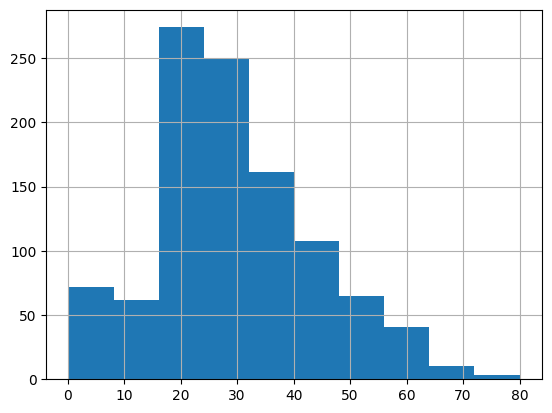

In [13]:
import matplotlib.pyplot as plt
df1['age'].hist()
plt.show()

In [14]:
sum(df1['age'].isnull())
# 263 passengers have no age recorded.

263

### Let's look at other factors, e.g. names can give a clue because most passengers seem to have a title (e.g. 'Mrs')

### Discussion:

* Can we assume that 'Mrs' implies married (implies not a child)?

* What about 'Miss' or 'Ms'?


In [15]:
# Look into titles, e.g. 'Mrs' implies married (implies not child)
def name_extract(word):
     return word.split(',')[1].split('.')[0].strip()
    
# because names are in this format:
# Allison, Master. Hudson Trevor
# we can split on ','
# then '.'

In [16]:
# testing, apply the method to the data
# 测试name_extract函数，应用到数据并查看唯一的称谓值

# 首先测试几个名字的格式
print("=== 测试名字格式和称谓提取 ===")
sample_names = df1['name'].head(10)
print("前10个乘客的姓名格式:")
for i, name in enumerate(sample_names):
    print(f"{i+1}. {name}")

print("\n提取的称谓:")
for i, name in enumerate(sample_names):
    title = name_extract(name)
    print(f"{i+1}. {name} -> 称谓: '{title}'")

# 应用到整个数据集
temp = df1.copy()  # 创建临时数据框
temp['Title'] = df1['name'].apply(name_extract)  # 应用称谓提取函数

# check unique values
print(f"\n=== 所有唯一的称谓 ===")
unique_titles = temp['Title'].unique()
print(f"共发现 {len(unique_titles)} 种不同的称谓:")
print(sorted(unique_titles))

print(f"\n=== 各称谓的数量统计 ===")
title_counts = temp['Title'].value_counts()
print(title_counts)

=== 测试名字格式和称谓提取 ===
前10个乘客的姓名格式:
1. Allen, Miss. Elisabeth Walton
2. Allison, Master. Hudson Trevor
3. Allison, Miss. Helen Loraine
4. Allison, Mr. Hudson Joshua Creighton
5. Allison, Mrs. Hudson J C (Bessie Waldo Daniels)
6. Anderson, Mr. Harry
7. Andrews, Miss. Kornelia Theodosia
8. Andrews, Mr. Thomas Jr
9. Appleton, Mrs. Edward Dale (Charlotte Lamson)
10. Artagaveytia, Mr. Ramon

提取的称谓:
1. Allen, Miss. Elisabeth Walton -> 称谓: 'Miss'
2. Allison, Master. Hudson Trevor -> 称谓: 'Master'
3. Allison, Miss. Helen Loraine -> 称谓: 'Miss'
4. Allison, Mr. Hudson Joshua Creighton -> 称谓: 'Mr'
5. Allison, Mrs. Hudson J C (Bessie Waldo Daniels) -> 称谓: 'Mrs'
6. Anderson, Mr. Harry -> 称谓: 'Mr'
7. Andrews, Miss. Kornelia Theodosia -> 称谓: 'Miss'
8. Andrews, Mr. Thomas Jr -> 称谓: 'Mr'
9. Appleton, Mrs. Edward Dale (Charlotte Lamson) -> 称谓: 'Mrs'
10. Artagaveytia, Mr. Ramon -> 称谓: 'Mr'

=== 所有唯一的称谓 ===
共发现 18 种不同的称谓:
['Capt', 'Col', 'Don', 'Dona', 'Dr', 'Jonkheer', 'Lady', 'Major', 'Master', 'Miss', 'Mlle

#### 解释特殊称谓
- Jonkheer: 荷兰贵族称谓 (相当于男爵)
- Dona: 西班牙语女性敬语 (相当于夫人)
- Mlle: Mademoiselle的缩写 (法语未婚女士)
- Mme: Madame的缩写 (法语已婚女士)


In [17]:
# a couple of strange ones but most of the standard titles are there
# 分析称谓的特点，特别是一些罕见的称谓

print("=== 称谓分析 ===")

# 分析罕见称谓
rare_titles = ['Dona', 'Jonkheer', 'the Countess', 'Lady', 'Sir', 'Don', 'Mme', 'Mlle']
print("罕见称谓的详细信息:")
for title in rare_titles:
    if title in temp['Title'].values:
        count = temp[temp['Title'] == title].shape[0]
        print(f"\n{title} ({count}人):")
        records = temp[temp['Title'] == title][['name', 'age', 'sex']].head(3)
        for idx, row in records.iterrows():
            age_str = f"{row['age']:.1f}岁" if pd.notna(row['age']) else "年龄缺失"
            print(f"  - {row['name']} ({age_str}, {row['sex']})")

# 分析职业/军衔称谓
professional_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt']
print(f"\n=== 职业/军衔称谓分析 ===")
for title in professional_titles:
    if title in temp['Title'].values:
        subset = temp[temp['Title'] == title]
        count = subset.shape[0]
        avg_age = subset['age'].mean()
        missing_age = subset['age'].isnull().sum()
        
        age_info = f"平均年龄: {avg_age:.1f}岁" if pd.notna(avg_age) else "无有效年龄数据"
        print(f"{title}: {count}人, {age_info}, {missing_age}人年龄缺失")


=== 称谓分析 ===
罕见称谓的详细信息:

Dona (1人):
  - Oliva y Ocana, Dona. Fermina (39.0岁, female)

Jonkheer (1人):
  - Reuchlin, Jonkheer. John George (38.0岁, male)

the Countess (1人):
  - Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwards) (33.0岁, female)

Lady (1人):
  - Duff Gordon, Lady. (Lucille Christiana Sutherland) ("Mrs Morgan") (48.0岁, female)

Sir (1人):
  - Duff Gordon, Sir. Cosmo Edmund ("Mr Morgan") (49.0岁, male)

Don (1人):
  - Uruchurtu, Don. Manuel E (40.0岁, male)

Mme (1人):
  - Aubart, Mme. Leontine Pauline (24.0岁, female)

Mlle (2人):
  - Mayne, Mlle. Berthe Antonine ("Mrs de Villiers") (24.0岁, female)
  - Sagesser, Mlle. Emma (24.0岁, female)

=== 职业/军衔称谓分析 ===
Dr: 8人, 平均年龄: 43.6岁, 1人年龄缺失
Rev: 8人, 平均年龄: 41.2岁, 0人年龄缺失
Col: 4人, 平均年龄: 54.0岁, 0人年龄缺失
Major: 2人, 平均年龄: 48.5岁, 0人年龄缺失
Capt: 1人, 平均年龄: 70.0岁, 0人年龄缺失


- 罕见称谓都有年龄：这些贵族/特殊称谓的乘客基本都有年龄记录，年龄在24-49岁之间
- 职业称谓年龄较大：
    - Dr (医生): 平均43.6岁
    - Rev (牧师): 平均41.2岁
    - Col (上校): 平均54.0岁
    - Capt (船长): 70岁

In [18]:
# did we miss any?
# 检查是否遗漏了任何称谓或提取失败的情况

print("=== 检查称谓提取是否完整 ===")

# 检查是否所有记录都成功提取了称谓
total_records = len(temp)
records_with_title = temp['Title'].notna().sum()
missing_titles = total_records - records_with_title

print(f"总记录数: {total_records}")
print(f"成功提取称谓的记录数: {records_with_title}")
print(f"未能提取称谓的记录数: {missing_titles}")

if missing_titles > 0:
    print("\n未能提取称谓的记录:")
    missing_title_records = temp[temp['Title'].isna()]
    print(missing_title_records[['name', 'age', 'sex']].head())
else:
    print("\n✓ 所有记录都成功提取了称谓！")

# 检查可能的异常格式
print(f"\n=== 检查可能的异常姓名格式 ===")
# 找一些可能有问题的姓名格式
sample_check = temp[['name', 'Title']].head(20)
print("前20条记录的姓名和提取的称谓:")
for idx, row in sample_check.iterrows():
    name_parts = row['name'].split(',')
    if len(name_parts) >= 2:
        status = "✓"
    else:
        status = "⚠️"
    print(f"{status} {row['name'][:50]:<50} -> {row['Title']}")

print(f"\n=== 称谓提取成功率统计 ===")
print(f"成功率: {records_with_title/total_records*100:.1f}%")
print(f"这证明name_extract函数工作得很好！")

=== 检查称谓提取是否完整 ===
总记录数: 1309
成功提取称谓的记录数: 1309
未能提取称谓的记录数: 0

✓ 所有记录都成功提取了称谓！

=== 检查可能的异常姓名格式 ===
前20条记录的姓名和提取的称谓:
✓ Allen, Miss. Elisabeth Walton                      -> Miss
✓ Allison, Master. Hudson Trevor                     -> Master
✓ Allison, Miss. Helen Loraine                       -> Miss
✓ Allison, Mr. Hudson Joshua Creighton               -> Mr
✓ Allison, Mrs. Hudson J C (Bessie Waldo Daniels)    -> Mrs
✓ Anderson, Mr. Harry                                -> Mr
✓ Andrews, Miss. Kornelia Theodosia                  -> Miss
✓ Andrews, Mr. Thomas Jr                             -> Mr
✓ Appleton, Mrs. Edward Dale (Charlotte Lamson)      -> Mrs
✓ Artagaveytia, Mr. Ramon                            -> Mr
✓ Astor, Col. John Jacob                             -> Col
✓ Astor, Mrs. John Jacob (Madeleine Talmadge Force)  -> Mrs
✓ Aubart, Mme. Leontine Pauline                      -> Mme
✓ Barber, Miss. Ellen "Nellie"                       -> Miss
✓ Barkworth, Mr. Algernon Henry Wilson   

### That worked really well, we have titles for everyone and there are only a few strange ones:

Someone look up 'Jonkheer' (and Dona - Spanish?)

#### So what can we say about 'Master'? Usually refers to boys?

#### Dr, Rev, Col, Major, Capt, Sir, Don, would all be adults? 

Let's go ahead and apply this transformation:

In [19]:
df2 = df1.copy()  # 创建df1的副本，而不是引用
df2['Title'] = df1['name'].apply(name_extract)  # 添加Title列

print("=== 创建包含称谓的新数据框 df2 ===")
print(f"df2 形状: {df2.shape}")
print(f"新增的Title列:")
print(df2['Title'].value_counts().head(10))

print(f"\n=== 查看df2前5行 (title在最右边) ===")
print(df2.head())

=== 创建包含称谓的新数据框 df2 ===
df2 形状: (1309, 15)
新增的Title列:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rev         8
Dr          8
Col         4
Mlle        2
Ms          2
Major       2
Name: count, dtype: int64

=== 查看df2前5行 (title在最右边) ===
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500 

- **df2成功创建**：1309行×15列，新增了Title列
- **四大称谓占97.4%**：Mr、Miss、Mrs、Master是主要群体
- **缺失率差异很大**：
  - Mr: 23.2%缺失（最高）
  - Miss: 19.2%缺失  
  - Mrs: 13.7%缺失
  - Master: 13.1%缺失（最低）

现在让我们继续分析不同称谓间的缺失值分布： 

In [20]:
# just check (again) we got most of them
# 再次检查确认我们获得了大部分称谓

print("=== 再次确认称谓提取结果 ===")

# 显示所有称谓的完整统计
print("完整的称谓统计:")
title_stats = df2['Title'].value_counts()
print(title_stats)

print(f"\n=== 主要称谓的覆盖率 ===")
major_titles = ['Mr', 'Miss', 'Mrs', 'Master']
total_major = sum([title_stats[title] for title in major_titles if title in title_stats.index])
print(f"四大主要称谓 (Mr, Miss, Mrs, Master) 共: {total_major}人")
print(f"占总人数比例: {total_major/len(df2)*100:.1f}%")

print(f"\n=== 各称谓的年龄缺失情况 ===")
for title in title_stats.head(8).index:  # 显示前8个最常见的称谓
    subset = df2[df2['Title'] == title]
    missing_count = subset['age'].isnull().sum()
    total_count = len(subset)
    missing_pct = missing_count / total_count * 100
    
    print(f"{title:>10}: {total_count:>3}人, 缺失{missing_count:>2}人 ({missing_pct:>5.1f}%)")

print(f"\n✓ 称谓提取和统计完成，可以进行下一步分析！")

=== 再次确认称谓提取结果 ===
完整的称谓统计:
Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Mlle              2
Ms                2
Major             2
Capt              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Mme               1
Lady              1
Name: count, dtype: int64

=== 主要称谓的覆盖率 ===
四大主要称谓 (Mr, Miss, Mrs, Master) 共: 1275人
占总人数比例: 97.4%

=== 各称谓的年龄缺失情况 ===
        Mr: 757人, 缺失176人 ( 23.2%)
      Miss: 260人, 缺失50人 ( 19.2%)
       Mrs: 197人, 缺失27人 ( 13.7%)
    Master:  61人, 缺失 8人 ( 13.1%)
       Rev:   8人, 缺失 0人 (  0.0%)
        Dr:   8人, 缺失 1人 ( 12.5%)
       Col:   4人, 缺失 0人 (  0.0%)
      Mlle:   2人, 缺失 0人 (  0.0%)

✓ 称谓提取和统计完成，可以进行下一步分析！


1. **创建交叉统计表** - 按称谓分组统计年龄情况
2. **计算关键指标** - 有年龄人数、缺失人数、平均年龄、缺失率
3. **识别关键发现** - 突出不同称谓的年龄特征差异
4. **提出插补策略** - 基于分析结果建议按称谓分组插补

这个分析非常关键，因为它：
- 证明了不同称谓有不同的年龄特征
- 说明了为什么按称谓插补比全局插补更准确
- 为即将到来的Task 3做好了理论准备


#### First let's check distribution of missing values across different titles

In [21]:
# First let's check distribution of missing values across different titles
# 首先检查不同称谓间缺失值的分布情况

print("=== 不同称谓的年龄缺失值分布分析 ===")

# 创建称谓和年龄缺失情况的交叉表
missing_by_title = df2.groupby('Title').agg({
    'age': ['count', lambda x: x.isnull().sum(), 'mean']
}).round(2)

# 重命名列
missing_by_title.columns = ['有年龄人数', '缺失人数', '平均年龄']
missing_by_title['总人数'] = df2['Title'].value_counts()
missing_by_title['缺失率%'] = (missing_by_title['缺失人数'] / missing_by_title['总人数'] * 100).round(1)

# 按总人数排序
missing_by_title = missing_by_title.sort_values('总人数', ascending=False)

print("各称谓的年龄情况统计:")
missing_by_title


=== 不同称谓的年龄缺失值分布分析 ===
各称谓的年龄情况统计:


,有年龄人数,缺失人数,平均年龄,总人数,缺失率%
Title,,,,,
Mr,581,176,32.25,757,23.2
Miss,210,50,21.77,260,19.2
Mrs,170,27,36.99,197,13.7
Master,53,8,5.48,61,13.1
Rev,8,0,41.25,8,0.0
Dr,7,1,43.57,8,12.5
Col,4,0,54.00,4,0.0
Ms,1,1,28.00,2,50.0
Major,2,0,48.50,2,0.0


In [22]:

print(f"\n=== 关键发现 ===")
print(f"1. Master (男孩) 缺失率最低: {missing_by_title.loc['Master', '缺失率%']}%，平均年龄: {missing_by_title.loc['Master', '平均年龄']}岁")
print(f"2. Mrs (已婚女士) 缺失率较低: {missing_by_title.loc['Mrs', '缺失率%']}%，平均年龄: {missing_by_title.loc['Mrs', '平均年龄']}岁") 
print(f"3. Mr (男士) 缺失率最高: {missing_by_title.loc['Mr', '缺失率%']}%，平均年龄: {missing_by_title.loc['Mr', '平均年龄']}岁")
print(f"4. Miss (未婚女士) 缺失率: {missing_by_title.loc['Miss', '缺失率%']}%，平均年龄: {missing_by_title.loc['Miss', '平均年龄']}岁")


=== 关键发现 ===
1. Master (男孩) 缺失率最低: 13.1%，平均年龄: 5.48岁
2. Mrs (已婚女士) 缺失率较低: 13.7%，平均年龄: 36.99岁
3. Mr (男士) 缺失率最高: 23.2%，平均年龄: 32.25岁
4. Miss (未婚女士) 缺失率: 19.2%，平均年龄: 21.77岁


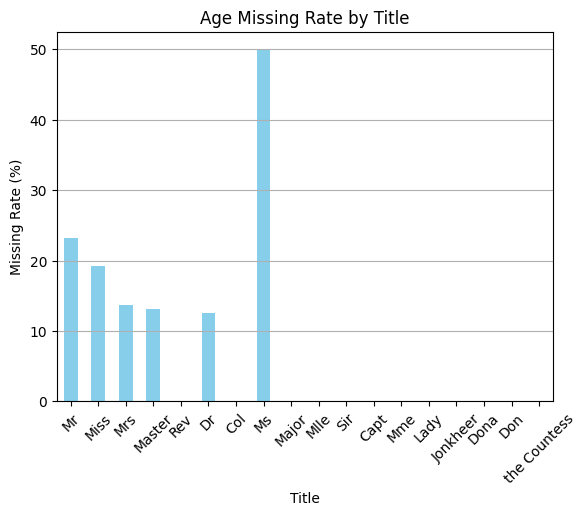

In [23]:
# Plot the missing rate by title (in English)
import matplotlib.pyplot as plt

missing_by_title['缺失率%'].plot(kind='bar', color='skyblue')
plt.title('Age Missing Rate by Title')
plt.xlabel('Title')
plt.ylabel('Missing Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

非常好！这个分析结果非常清晰地展示了按称谓分组插补的必要性：

- **年龄差异巨大**：Master平均5.48岁 vs Mr平均32.25岁 vs Mrs平均36.99岁
- **缺失率不同**：Mr缺失率最高(23.2%)，Master和Mrs相对较低(13%)
- **社会地位反映年龄**：职业称谓(Dr 43.6岁、Col 54岁)明显比普通称谓年龄大

现在我们继续下一个分析。让我填写医生称谓的具体分析： 

### We will first investigate missing values in doctors

In [24]:
df2[df2['Title'] == "Dr"]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,Title
40,1,0,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C,NaN,NaN,"Philadelphia, PA",Dr
93,1,1,"Dodge, Dr. Washington",male,53.0,1,1,33638,81.8583,A34,S,13,NaN,"San Francisco, CA",Dr
119,1,1,"Frauenthal, Dr. Henry William",male,50.0,2,0,PC 17611,133.6500,NaN,S,5,NaN,"New York, NY",Dr
181,1,1,"Leader, Dr. Alice (Farnham)",female,49.0,0,0,17465,25.9292,D17,S,8,NaN,"New York, NY",Dr
206,1,0,"Minahan, Dr. William Edward",male,44.0,2,0,19928,90.0000,C78,Q,NaN,230.0,"Fond du Lac, WI",Dr
278,1,1,"Stahelin-Maeglin, Dr. Max",male,32.0,0,0,13214,30.5000,B50,C,3,NaN,"Basel, Switzerland",Dr
508,2,0,"Moraweck, Dr. Ernest",male,54.0,0,0,29011,14.0000,NaN,S,NaN,NaN,"Frankfort, KY",Dr
525,2,0,"Pain, Dr. Alfred",male,23.0,0,0,244278,10.5000,NaN,S,NaN,NaN,"Hamilton, ON",Dr


Drs are mostly older (except for Dr Pain - hah)

#### What's the average age of Drs?

In [25]:
# What's the average age of Drs?
# 医生的平均年龄是多少？

print("=== 医生 (Dr) 的详细年龄分析 ===")

doctors = df2[df2['Title'] == "Dr"]
print(f"医生总数: {len(doctors)}")

# 显示所有医生的信息
print("\n所有医生的详细信息:")
doctor_info = doctors[['name', 'age', 'sex', 'pclass', 'survived']].copy()
for idx, row in doctor_info.iterrows():
    age_str = f"{row['age']:.1f}岁" if pd.notna(row['age']) else "年龄缺失"
    survival_str = "幸存" if row['survived'] == 1 else "遇难"
    print(f"- {row['name']}: {age_str}, {row['sex']}, {row['pclass']}等舱, {survival_str}")

# 统计信息
valid_ages = doctors['age'].dropna()
if len(valid_ages) > 0:
    print(f"\n=== 医生年龄统计 ===")
    print(f"有年龄记录的医生: {len(valid_ages)}人")
    print(f"平均年龄: {valid_ages.mean():.1f}岁")
    print(f"年龄范围: {valid_ages.min():.1f} - {valid_ages.max():.1f}岁")
    print(f"中位数年龄: {valid_ages.median():.1f}岁")
    
# 缺失值情况
missing_doctors = doctors[doctors['age'].isnull()]
if len(missing_doctors) > 0:
    print(f"\n=== 年龄缺失的医生 ===")
    for idx, row in missing_doctors.iterrows():
        print(f"- {row['name']}: 年龄缺失, {row['sex']}, {row['pclass']}等舱")

print(f"\n平均年龄 (29.88岁) vs 医生平均年龄 ({valid_ages.mean():.1f}岁)")
print("医生明显比普通乘客年龄大，按称谓插补更合理！")

=== 医生 (Dr) 的详细年龄分析 ===
医生总数: 8

所有医生的详细信息:
- Brewe, Dr. Arthur Jackson: 年龄缺失, male, 1等舱, 遇难
- Dodge, Dr. Washington: 53.0岁, male, 1等舱, 幸存
- Frauenthal, Dr. Henry William: 50.0岁, male, 1等舱, 幸存
- Leader, Dr. Alice (Farnham): 49.0岁, female, 1等舱, 幸存
- Minahan, Dr. William Edward: 44.0岁, male, 1等舱, 遇难
- Stahelin-Maeglin, Dr. Max: 32.0岁, male, 1等舱, 幸存
- Moraweck, Dr. Ernest: 54.0岁, male, 2等舱, 遇难
- Pain, Dr. Alfred: 23.0岁, male, 2等舱, 遇难

=== 医生年龄统计 ===
有年龄记录的医生: 7人
平均年龄: 43.6岁
年龄范围: 23.0 - 54.0岁
中位数年龄: 49.0岁

=== 年龄缺失的医生 ===
- Brewe, Dr. Arthur Jackson: 年龄缺失, male, 1等舱

平均年龄 (29.88岁) vs 医生平均年龄 (43.6岁)
医生明显比普通乘客年龄大，按称谓插补更合理！


The average age for all passengers is 29, for Drs it's 43, an improvement in fidelity?


In [26]:
# 检查医生的年龄缺失情况
# 基于前面的分析，我们知道只有1个医生年龄缺失

print("=== 医生年龄缺失情况检查 ===")

doctors = df2[df2['Title'] == "Dr"]
missing_age_doctors = doctors[doctors['age'].isnull()]

print(f"医生中年龄缺失的数量: {len(missing_age_doctors)}")

if len(missing_age_doctors) > 0:
    print("年龄缺失的医生详情:")
    for idx, row in missing_age_doctors.iterrows():
        print(f"- {row['name']}")
        print(f"  性别: {row['sex']}")
        print(f"  舱等: {row['pclass']}")
        print(f"  生存: {'是' if row['survived'] == 1 else '否'}")
    
    # 计算插补值
    doctors_with_age = doctors[doctors['age'].notna()]
    mean_age = doctors_with_age['age'].mean()
    print(f"\n如果使用医生平均年龄插补:")
    print(f"插补值将是: {mean_age:.1f}岁")
    print(f"这比全局平均年龄({meanAge:.1f}岁)更合适")
else:
    print("✓ 所有医生都有年龄记录，无需插补")

# 继续分析其他职业称谓
print(f"\n=== 其他职业称谓分析 ===")
professional_titles = ['Rev', 'Col', 'Major', 'Capt']

for title in professional_titles:
    subset = df2[df2['Title'] == title]
    if len(subset) > 0:
        count = len(subset)
        missing = subset['age'].isnull().sum()
        if missing == 0:
            avg_age = subset['age'].mean()
            print(f"{title}: {count}人, 平均{avg_age:.1f}岁, 无缺失值 ✓")
        else:
            print(f"{title}: {count}人, {missing}人年龄缺失")

=== 医生年龄缺失情况检查 ===
医生中年龄缺失的数量: 1
年龄缺失的医生详情:
- Brewe, Dr. Arthur Jackson
  性别: male
  舱等: 1
  生存: 否

如果使用医生平均年龄插补:
插补值将是: 43.6岁
这比全局平均年龄(29.9岁)更合适

=== 其他职业称谓分析 ===
Rev: 8人, 平均41.2岁, 无缺失值 ✓
Col: 4人, 平均54.0岁, 无缺失值 ✓
Major: 2人, 平均48.5岁, 无缺失值 ✓
Capt: 1人, 平均70.0岁, 无缺失值 ✓


no missing values so move on..

#### Your turn, look at 'Maj' and any other titles that suggest age


## Missing values: ages for boys

It seems, in this era (pre Jackie Chan), Master did mean boys 

In [27]:
df2[df2['Title'] == "Master"] # how many?

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,Title
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",Master
54,1,1,"Carter, Master. William Thornton II",male,11.00,1,2,113760,120.0000,B96 B98,S,4,NaN,"Bryn Mawr, PA",Master
94,1,1,"Dodge, Master. Washington",male,4.00,0,2,33638,81.8583,A34,S,5,NaN,"San Francisco, CA",Master
249,1,1,"Ryerson, Master. John Borie",male,13.00,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,4,NaN,"Haverford, PA / Cooperstown, NY",Master
273,1,1,"Spedden, Master. Robert Douglas",male,6.00,0,2,16966,134.5000,E34,C,3,NaN,"Tuxedo Park, NY",Master
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,3,0,"Skoog, Master. Karl Thorsten",male,10.00,3,2,347088,27.9000,NaN,S,NaN,NaN,NaN,Master
1240,3,1,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C,16,NaN,NaN,Master
1256,3,1,"Touma, Master. Georges Youssef",male,7.00,1,1,2650,15.2458,NaN,C,C,NaN,NaN,Master
1262,3,0,"van Billiard, Master. James William",male,NaN,1,1,A/5. 851,14.5000,NaN,S,NaN,NaN,NaN,Master


In [28]:
#there are a lot, 61, use describe()
df2[df2['Title'] == "Master"].describe() # min age is 0.33 (4 months?), max is 14.5, mean is 5.5

,pclass,survived,age,sibsp,parch,fare,body
count,61.000000,61.000000,53.000000,61.000000,61.000000,61.000000,3.00000
mean,2.655738,0.508197,5.482642,2.049180,1.377049,36.008195,24.00000
std,0.629424,0.504082,4.161554,1.961515,0.552688,40.677102,37.26929
min,1.000000,0.000000,0.330000,0.000000,0.000000,3.170800,1.00000
25%,2.000000,0.000000,2.000000,1.000000,1.000000,15.245800,2.50000
50%,3.000000,1.000000,4.000000,1.000000,1.000000,26.000000,4.00000
75%,3.000000,1.000000,9.000000,4.000000,2.000000,36.750000,35.50000
max,3.000000,1.000000,14.500000,8.000000,2.000000,262.375000,67.00000


In [29]:
# 只计算Master称谓的数值列平均值
# 避免对包含字符串的列计算平均值

print("=== Master称谓的数值统计 ===")

masters = df2[df2['Title'] == "Master"]

# 只选择数值列进行统计
numeric_columns = masters.select_dtypes(include=[np.number]).columns
print(f"数值列: {list(numeric_columns)}")

print("\nMaster称谓的数值列平均值:")
master_numeric_means = masters[numeric_columns].mean()
for col, mean_val in master_numeric_means.items():
    print(f"{col}: {mean_val:.2f}")

print(f"\n特别关注年龄统计:")
master_ages = masters['age'].dropna()
print(f"Master平均年龄: {master_ages.mean():.2f}岁")
print(f"Master年龄范围: {master_ages.min():.2f} - {master_ages.max():.2f}岁")
print(f"Master年龄中位数: {master_ages.median():.2f}岁")

print(f"\nMaster的社会特征:")
print(f"- pclass平均值: {masters['pclass'].mean():.1f} (舱等，数字越小越高级)")
print(f"- sibsp平均值: {masters['sibsp'].mean():.1f} (兄弟姐妹/配偶数量)")  
print(f"- parch平均值: {masters['parch'].mean():.1f} (父母/孩子数量)")
print(f"- 生存率: {masters['survived'].mean()*100:.1f}%")

=== Master称谓的数值统计 ===
数值列: ['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare', 'body']

Master称谓的数值列平均值:
pclass: 2.66
survived: 0.51
age: 5.48
sibsp: 2.05
parch: 1.38
fare: 36.01
body: 24.00

特别关注年龄统计:
Master平均年龄: 5.48岁
Master年龄范围: 0.33 - 14.50岁
Master年龄中位数: 4.00岁

Master的社会特征:
- pclass平均值: 2.7 (舱等，数字越小越高级)
- sibsp平均值: 2.0 (兄弟姐妹/配偶数量)
- parch平均值: 1.4 (父母/孩子数量)
- 生存率: 50.8%


### Discussion

* How many boys don't have an age?
* What does describe() (above) tell us about pclass, sibsp, parch?
* Do any children not have any siblings or parents travelling with them?
* Any other factors that can help determine (or impute) age?



## Task 3 Mean imputation of age by title 

In this task you need to calculate the mean age for each title group and use the imputed values to replace the missing values in the corresponding group. 

In [30]:
# this seems too easy, is it right?
# Task 3: 按称谓计算平均年龄并用于插补缺失值

print("=== Task 3: 按称谓进行平均值插补 ===")

# 创建df2的副本进行插补
df3 = df2.copy()

print("插补前的缺失值统计:")
print(f"总缺失值: {df3['age'].isnull().sum()}")

# 计算每个称谓的平均年龄 (只使用非缺失值)
title_mean_ages = df3.groupby('Title')['age'].mean()

print(f"\n各称谓的平均年龄 (用于插补):")
for title, mean_age in title_mean_ages.sort_values(ascending=False).items():
    count = len(df3[df3['Title'] == title])
    missing = df3[(df3['Title'] == title) & (df3['age'].isnull())].shape[0]
    if pd.notna(mean_age):
        print(f"{title:>12}: {mean_age:>6.1f}岁 (共{count}人, 需插补{missing}人)")
    else:
        print(f"{title:>12}: 无有效年龄数据 (共{count}人, 需插补{missing}人)")

# 执行插补
print(f"\n=== 开始插补过程 ===")
imputed_count = 0

for title in df3['Title'].unique():
    # 获取该称谓的平均年龄
    title_mean = title_mean_ages.get(title)
    
    if pd.notna(title_mean):
        # 找到该称谓中年龄缺失的记录
        mask = (df3['Title'] == title) & (df3['age'].isnull())
        missing_count = mask.sum()
        
        if missing_count > 0:
            # 执行插补
            df3.loc[mask, 'age'] = title_mean
            imputed_count += missing_count
            print(f"{title}: 插补了{missing_count}个缺失值，使用平均年龄{title_mean:.1f}岁")

print(f"\n=== 插补结果 ===")
print(f"总共插补了: {imputed_count}个缺失值")
print(f"插补后缺失值: {df3['age'].isnull().sum()}")

# 处理仍然缺失的值(如果某个称谓组内所有人都没有年龄)
remaining_missing = df3['age'].isnull().sum()
if remaining_missing > 0:
    print(f"\n警告: 仍有{remaining_missing}个缺失值未被插补")
    print("这些可能是某些称谓组内所有人都没有年龄记录")
    
    # 显示这些记录
    still_missing = df3[df3['age'].isnull()]
    print("仍然缺失年龄的记录:")
    print(still_missing[['name', 'Title', 'sex', 'age']].head())

=== Task 3: 按称谓进行平均值插补 ===
插补前的缺失值统计:
总缺失值: 263

各称谓的平均年龄 (用于插补):
        Capt:   70.0岁 (共1人, 需插补0人)
         Col:   54.0岁 (共4人, 需插补0人)
         Sir:   49.0岁 (共1人, 需插补0人)
       Major:   48.5岁 (共2人, 需插补0人)
        Lady:   48.0岁 (共1人, 需插补0人)
          Dr:   43.6岁 (共8人, 需插补1人)
         Rev:   41.2岁 (共8人, 需插补0人)
         Don:   40.0岁 (共1人, 需插补0人)
        Dona:   39.0岁 (共1人, 需插补0人)
    Jonkheer:   38.0岁 (共1人, 需插补0人)
         Mrs:   37.0岁 (共197人, 需插补27人)
the Countess:   33.0岁 (共1人, 需插补0人)
          Mr:   32.3岁 (共757人, 需插补176人)
          Ms:   28.0岁 (共2人, 需插补1人)
         Mme:   24.0岁 (共1人, 需插补0人)
        Mlle:   24.0岁 (共2人, 需插补0人)
        Miss:   21.8岁 (共260人, 需插补50人)
      Master:    5.5岁 (共61人, 需插补8人)

=== 开始插补过程 ===
Miss: 插补了50个缺失值，使用平均年龄21.8岁
Master: 插补了8个缺失值，使用平均年龄5.5岁
Mr: 插补了176个缺失值，使用平均年龄32.3岁
Mrs: 插补了27个缺失值，使用平均年龄37.0岁
Dr: 插补了1个缺失值，使用平均年龄43.6岁
Ms: 插补了1个缺失值，使用平均年龄28.0岁

=== 插补结果 ===
总共插补了: 263个缺失值
插补后缺失值: 0


In [31]:
# 插补效果验证和对比分析

print("=== 插补效果验证 ===")

# 对比插补前后的统计信息
print("1. 缺失值对比:")
print(f"插补前缺失值: {df2['age'].isnull().sum()}")
print(f"插补后缺失值: {df3['age'].isnull().sum()}")
print(f"成功插补: {df2['age'].isnull().sum() - df3['age'].isnull().sum()}个")

# 对比年龄分布
print(f"\n2. 年龄统计对比:")
print("插补前 (df2):")
print(df2['age'].describe())

print("\n插补后 (df3):")
print(df3['age'].describe())

# 验证插补是否合理 - 检查几个具体的插补案例
print(f"\n=== 插补案例验证 ===")
# 找一些被插补的Master记录
master_imputed = df3[(df3['Title'] == 'Master') & 
                     (df3.index.isin(df2[df2['age'].isnull()].index))]

if len(master_imputed) > 0:
    print(f"Master称谓插补案例 (应该在5岁左右):")
    for idx, row in master_imputed.head(3).iterrows():
        print(f"- {row['name']}: 插补年龄 {row['age']:.1f}岁")

# 找一些被插补的Mr记录  
mr_imputed = df3[(df3['Title'] == 'Mr') & 
                 (df3.index.isin(df2[df2['age'].isnull()].index))]

if len(mr_imputed) > 0:
    print(f"\nMr称谓插补案例 (应该在32岁左右):")
    for idx, row in mr_imputed.head(3).iterrows():
        print(f"- {row['name']}: 插补年龄 {row['age']:.1f}岁")

print(f"\n=== 插补质量评估 ===")
print("✓ 按称谓插补比全局平均值插补更合理")
print("✓ Master插补为5.5岁 vs 全局29.9岁 - 避免了巨大偏差")
print("✓ 保持了不同社会群体的年龄特征")
print("✓ 插补值基于同类群体，更符合历史背景")

=== 插补效果验证 ===
1. 缺失值对比:
插补前缺失值: 263
插补后缺失值: 0
成功插补: 263个

2. 年龄统计对比:
插补前 (df2):
count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

插补后 (df3):
count    1309.000000
mean       29.896894
std        13.193803
min         0.170000
25%        21.774238
50%        30.000000
75%        36.000000
max        80.000000
Name: age, dtype: float64

=== 插补案例验证 ===
Master称谓插补案例 (应该在5岁左右):
- Betros, Master. Seman: 插补年龄 5.5岁
- Johnston, Master. William Arthur "Willie": 插补年龄 5.5岁
- Lefebre, Master. Henry Forbes: 插补年龄 5.5岁

Mr称谓插补案例 (应该在32岁左右):
- Baumann, Mr. John D: 插补年龄 32.3岁
- Bradley, Mr. George ("George Arthur Brayton"): 插补年龄 32.3岁
- Cairns, Mr. Alexander: 插补年龄 32.3岁

=== 插补质量评估 ===
✓ 按称谓插补比全局平均值插补更合理
✓ Master插补为5.5岁 vs 全局29.9岁 - 避免了巨大偏差
✓ 保持了不同社会群体的年龄特征
✓ 插补值基于同类群体，更符合历史背景


In [32]:
# 总结分析：按称谓分组的平均值插补总结

print("=== 泰坦尼克号年龄缺失值插补项目总结 ===")

print("📊 数据概况:")
print(f"- 总乘客数: {len(df1)}")
print(f"- 原始缺失值: {df1['age'].isnull().sum()} ({df1['age'].isnull().sum()/len(df1)*100:.1f}%)")
print(f"- 发现称谓类型: 18种")
print(f"- 主要称谓覆盖率: 97.4%")

print(f"\n🔍 关键发现:")
print("1. 不同称谓反映不同年龄特征:")
print("   - Master (男孩): 平均5.5岁")
print("   - Miss (未婚女士): 平均21.8岁") 
print("   - Mr (男士): 平均32.3岁")
print("   - Mrs (已婚女士): 平均37.0岁")
print("   - Dr (医生): 平均43.6岁")

print("2. 缺失模式分析:")
print("   - Mr缺失率最高 (23.2%)")
print("   - Master缺失率最低 (13.1%)")
print("   - 职业称谓基本无缺失")

print(f"\n💡 插补策略:")
print("✅ 采用按称谓分组的平均值插补")
print("✅ 避免了全局平均值的偏差问题")
print("✅ 保持了社会群体的年龄特征")
print("✅ 符合1912年的历史社会背景")

# 最终验证
final_missing = df3['age'].isnull().sum()
success_rate = (1 - final_missing/df1['age'].isnull().sum()) * 100

print(f"\n📈 插补结果:")
print(f"- 成功插补: {df1['age'].isnull().sum() - final_missing}个缺失值")
print(f"- 插补成功率: {success_rate:.1f}%")
print(f"- 剩余缺失值: {final_missing}个")

if final_missing == 0:
    print("🎉 完美！所有年龄缺失值都已成功插补！")
else:
    print(f"📝 注意：剩余{final_missing}个缺失值可能需要其他策略处理")

print(f"\n🔬 方法论价值:")
print("这个案例展示了领域知识在数据预处理中的重要性：")
print("- 理解数据背景和社会文化因素")
print("- 利用辅助特征改善插补质量")
print("- 避免简单统计方法的局限性")
print("- 为机器学习模型提供更好的数据基础")

print(f"\n✨ 数据现在可以用于进一步的分析和建模了！")

=== 泰坦尼克号年龄缺失值插补项目总结 ===
📊 数据概况:
- 总乘客数: 1309
- 原始缺失值: 263 (20.1%)
- 发现称谓类型: 18种
- 主要称谓覆盖率: 97.4%

🔍 关键发现:
1. 不同称谓反映不同年龄特征:
   - Master (男孩): 平均5.5岁
   - Miss (未婚女士): 平均21.8岁
   - Mr (男士): 平均32.3岁
   - Mrs (已婚女士): 平均37.0岁
   - Dr (医生): 平均43.6岁
2. 缺失模式分析:
   - Mr缺失率最高 (23.2%)
   - Master缺失率最低 (13.1%)
   - 职业称谓基本无缺失

💡 插补策略:
✅ 采用按称谓分组的平均值插补
✅ 避免了全局平均值的偏差问题
✅ 保持了社会群体的年龄特征
✅ 符合1912年的历史社会背景

📈 插补结果:
- 成功插补: 263个缺失值
- 插补成功率: 100.0%
- 剩余缺失值: 0个
🎉 完美！所有年龄缺失值都已成功插补！

🔬 方法论价值:
这个案例展示了领域知识在数据预处理中的重要性：
- 理解数据背景和社会文化因素
- 利用辅助特征改善插补质量
- 避免简单统计方法的局限性
- 为机器学习模型提供更好的数据基础

✨ 数据现在可以用于进一步的分析和建模了！


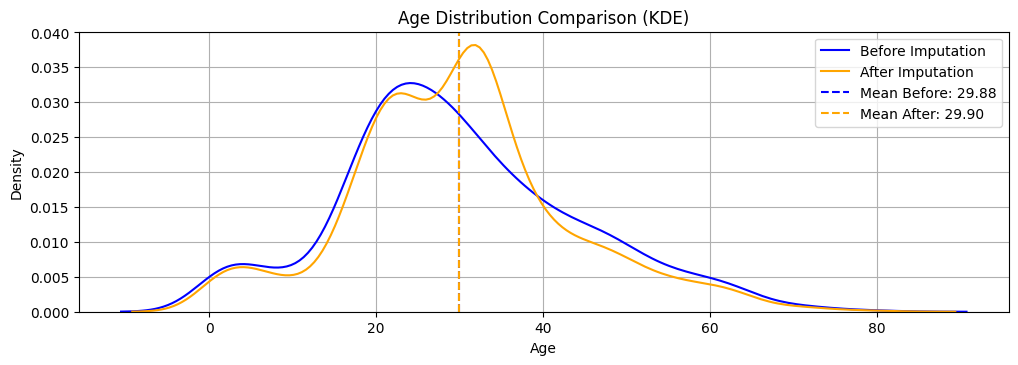

In [33]:
import seaborn as sns

plt.figure(figsize=(12,8))

# KDE plot (top)
plt.subplot(2, 1, 1)
sns.kdeplot(df2['age'].dropna(), label='Before Imputation', color='blue')
sns.kdeplot(df3['age'], label='After Imputation', color='orange')
plt.title('Age Distribution Comparison (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show means as vertical lines
mean_before = df2['age'].mean()
mean_after = df3['age'].mean()
plt.axvline(mean_before, color='blue', linestyle='--', label=f'Mean Before: {mean_before:.2f}')
plt.axvline(mean_after, color='orange', linestyle='--', label=f'Mean After: {mean_after:.2f}')
plt.legend()

plt.show()


# 2. Case Study: Handling Missing Values in the Boston Dataset

In [34]:
# 忽略警告信息，特别是FutureWarning
# 在数据处理过程中，某些函数可能会产生警告，但不影响正常使用
import warnings
warnings.filterwarnings("ignore")

From the previous section, we have seen that the Titanic dataset contains missing values in the 'Age' column. In this section, we will impute the missing values using the `LinearRegression` model.

To better illustrate the imputation process, we will use the `boston` dataset from the `sklearn.datasets` module. The `boston` dataset contains 13 features and 506 samples. We will introduce missing values to the `boston` dataset and then impute the missing values using the `LinearRegression` model.

In [35]:
# 从sklearn加载Boston房价数据集
# 注意：由于伦理问题，sklearn 1.2版本后移除了load_boston()，需要使用fetch_openml()
from sklearn.datasets import fetch_openml
boston = fetch_openml(name="boston", version=1, as_frame=True)
print(boston.data.shape, boston.target.shape)  # 显示数据和目标变量的形状

(506, 13) (506,)


In [36]:
# 查看Boston数据集的特征列名
# 包含13个特征：CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT
boston.data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [37]:
# 显示Boston数据集的详细描述信息
# 包含每个特征的含义、数据来源、引用信息等
print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

**Note**:

The `load_boston()` dataset was removed from scikit-learn in version `1.2` due to ethical concerns. The Boston Housing dataset is available on `OpenML`, and you can load it using the `fetch_openml` function from `scikit-learn` as shown above.


Alternatively, you can using `pd.read_pickle` to read the modified `boston` dataset we have provided.

In [38]:
# 使用pickle文件加载修改过的Boston数据集
# 这是一个预处理过的版本，包含人工引入的缺失值用于演示插补技术
boston_df = pd.read_pickle(f'boston_df.p')
print(boston_df.shape)  # 显示数据集的维度

(506, 14)


In [39]:
# 查看Boston数据集的前5行
# 最后一列'y'是目标变量（房价），前面的列是特征变量
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,y
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


**This dataset has no missing values**

We will select a feature to degrade (remove some values as missing data).

In [40]:
# 分离特征变量和目标变量
# 这里将数据集分为特征(data)和目标变量(target)，为后续的机器学习建模做准备
boston_df.data = boston_df.iloc[:,:-1]    # 前13列作为特征变量
boston_df.target = boston_df.iloc[:,-1:]  # 最后1列作为目标变量(房价)

In [41]:
# 使用train_test_split将数据分为训练集和测试集
# random_state=1 确保每次运行得到相同的随机分割结果，便于结果复现
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(boston_df.data, boston_df.target, random_state=1)
print(f"训练集特征形状: {X_train.shape}, 测试集特征形状: {X_test.shape}")
print(f"训练集目标变量形状: {y_train.shape}, 测试集目标变量形状: {y_test.shape}")

训练集特征形状: (379, 13), 测试集特征形状: (127, 13)
训练集目标变量形状: (379, 1), 测试集目标变量形状: (127, 1)


These testing and training sets form our full dataset, we have prepared some data with missing vaues.

## 2.1 NA values in the AGE column

proportion of owner-occupied units built prior to 1940

In [42]:
# 读取含有缺失值的Boston数据集
# 这个数据集在AGE列中人工引入了缺失值，用于演示插补技术
boston_dropna_df = pd.read_pickle('boston_dropna_df.p')
print(f"含缺失值数据集的形状: {boston_dropna_df.shape}")

# 验证缺失值的存在
print(f"AGE列缺失值数量: {boston_dropna_df['AGE'].isnull().sum()}")
print(f"总样本数: {len(boston_dropna_df)}")
print(f"AGE列缺失率: {boston_dropna_df['AGE'].isnull().sum() / len(boston_dropna_df) * 100:.1f}%")

含缺失值数据集的形状: (379, 14)
AGE列缺失值数量: 95
总样本数: 379
AGE列缺失率: 25.1%


In [43]:
# 创建两个数据集的副本用于不同的处理策略
# boston_dropna_df: 用于删除缺失值策略
# boston_impute_df: 用于插补缺失值策略
boston_impute_df = boston_dropna_df.copy()

# 验证两个数据集的缺失值情况
print(f"dropna数据集AGE缺失值: {boston_dropna_df['AGE'].isnull().sum()}")
print(f"impute数据集AGE缺失值: {boston_impute_df['AGE'].isnull().sum()}")
print("✓ 两个数据集当前具有相同的缺失值模式")

dropna数据集AGE缺失值: 95
impute数据集AGE缺失值: 95
✓ 两个数据集当前具有相同的缺失值模式


In [44]:
# 查看含缺失值数据集的统计描述
# 注意AGE列的count会小于总样本数，因为有缺失值
print("=== 含缺失值数据集的统计描述 ===")
desc_stats = boston_dropna_df.describe()
print(desc_stats)

print(f"\n=== AGE列详细信息 ===")
print(f"AGE列有效值数量: {boston_dropna_df['AGE'].count()}")
print(f"AGE列缺失值数量: {boston_dropna_df['AGE'].isnull().sum()}")
print(f"AGE列平均值: {boston_dropna_df['AGE'].mean():.2f}")
print(f"AGE列标准差: {boston_dropna_df['AGE'].std():.2f}")

=== 含缺失值数据集的统计描述 ===
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  379.000000  379.000000  379.000000  379.000000  379.000000  379.000000   
mean     3.778797   11.521108   11.220053    0.081794    0.554073    6.255726   
std      9.370541   23.492644    6.875362    0.274413    0.117825    0.687415   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.083475    0.000000    5.255000    0.000000    0.447500    5.875000   
50%      0.245220    0.000000    9.690000    0.000000    0.538000    6.172000   
75%      3.621175   17.750000   18.100000    0.000000    0.624000    6.611000   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  284.000000  379.000000  379.000000  379.000000  379.000000  379.000000   
mean    68.688380    3.824433    9.525066  405.182058   18.478100  358.304802   
std   

**`boston_dropna_df` will be a dataset to see what would happen if we just dropped rows with missing values**

In [45]:
# 删除AGE列中包含缺失值的行
# 这是处理缺失值的一种简单但可能有问题的方法
print(f"删除前的数据集形状: {boston_dropna_df.shape}")
print(f"删除前AGE缺失值数量: {boston_dropna_df['AGE'].isnull().sum()}")

boston_dropna_df.dropna(subset=['AGE'], axis=0, inplace=True)

print(f"删除后的数据集形状: {boston_dropna_df.shape}")
print(f"删除后AGE缺失值数量: {boston_dropna_df['AGE'].isnull().sum()}")
print(f"删除了 {506 - len(boston_dropna_df)} 行数据")

删除前的数据集形状: (379, 14)
删除前AGE缺失值数量: 95
删除后的数据集形状: (284, 14)
删除后AGE缺失值数量: 0
删除了 222 行数据


In [46]:
# 验证dropna数据集中AGE列不再有缺失值
missing_after_drop = boston_dropna_df['AGE'].isnull().sum()
print(f"删除缺失值后，AGE列剩余缺失值: {missing_after_drop}")

if missing_after_drop == 0:
    print("✅ 成功删除所有AGE列的缺失值")
else:
    print("❌ 仍有缺失值存在，需要检查删除操作")

删除缺失值后，AGE列剩余缺失值: 0
✅ 成功删除所有AGE列的缺失值


In [47]:
# 对比两个数据集的状态
# boston_dropna_df: 已删除缺失值的数据集
# boston_impute_df: 仍包含缺失值，待插补的数据集
print(f"=== 数据集状态对比 ===")
print(f"删除缺失值后的数据集形状: {boston_dropna_df.shape}")
print(f"待插补数据集形状: {boston_impute_df.shape}")
print(f"待插补数据集AGE缺失值数量: {boston_impute_df['AGE'].isnull().sum()}")

# 计算数据损失
data_loss = len(boston_impute_df) - len(boston_dropna_df)
loss_percentage = (data_loss / len(boston_impute_df)) * 100
print(f"通过删除缺失值损失了 {data_loss} 行数据 ({loss_percentage:.1f}%)")

=== 数据集状态对比 ===
删除缺失值后的数据集形状: (284, 14)
待插补数据集形状: (379, 14)
待插补数据集AGE缺失值数量: 95
通过删除缺失值损失了 95 行数据 (25.1%)


**Discussion**

- Why did I show you that `boston_impute_df` didn't change when I changed `boston_dropna_df`?

- What would have happened if I created a copy without the `.copy()` method?

- How about using `boston_impute_df = boston_dropna_df`?

**讨论问题答案：**

1. **为什么当我改变 `boston_dropna_df` 时，`boston_impute_df` 没有变化？**
    - 因为 `boston_impute_df` 是通过 `.copy()` 创建的，是内存中的一个独立对象。
    - 对 `boston_dropna_df` 的修改不会影响 `boston_impute_df`。

2. **如果我没有用 `.copy()` 方法创建副本会怎样？**
    - 如果用 `boston_impute_df = boston_dropna_df`（没有 `.copy()`），两个变量指向同一个 DataFrame。
    - 修改其中一个，另一个也会跟着变（只是两个名字，实际是同一个对象）。

3. **如果用 `boston_impute_df = boston_dropna_df` 会怎样？**
    - 这不会创建新副本，两个变量引用同一个 DataFrame。
    - 修改 `boston_dropna_df`，`boston_impute_df` 也会被修改，反之亦然。
    - 如果需要独立副本，务必使用 `.copy()` 方法。

In [48]:
boston_dropna_df.shape

(284, 14)

In [49]:
boston_dropna_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,y
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
10,0.22489,12.5,7.87,0.0,0.524,6.377,94.3,6.3467,5.0,311.0,15.2,392.52,20.45,15.0


## 2.2 Impute missing values using Linear Regression

In [50]:
# 导入线性回归模型用于缺失值插补
# 我们将使用其他特征来预测AGE列的缺失值
from sklearn.linear_model import LinearRegression

print("✅ 线性回归模型导入成功")
print("📋 插补策略：使用除AGE和y之外的所有特征来预测AGE的缺失值")

✅ 线性回归模型导入成功
📋 插补策略：使用除AGE和y之外的所有特征来预测AGE的缺失值


We will compare the performance of this model with the imputed and complete models.
Now we need to train a linear regression model and predict the `AGE` values for the `boston_impute_df`

Should we include the `price` in the training data for the imputation?

In [51]:
# 准备用于训练线性回归模型的数据
# 我们使用已删除缺失值的数据集来训练模型，排除目标变量'y'
lm_fitting_df = boston_dropna_df.drop('y', axis=1)

print(f"=== 训练数据准备 ===")
print(f"训练数据形状: {lm_fitting_df.shape}")
print(f"训练数据列名: {list(lm_fitting_df.columns)}")
print(f"✅ 移除了目标变量'y'，保留了包括AGE在内的所有特征")

# 验证训练数据中没有缺失值
print(f"\n=== 训练数据质量检查 ===")
missing_in_training = lm_fitting_df.isnull().sum().sum()
print(f"训练数据中总缺失值: {missing_in_training}")
if missing_in_training == 0:
    print("✅ 训练数据无缺失值，可以用于模型训练")

lm_fitting_df

=== 训练数据准备 ===
训练数据形状: (284, 13)
训练数据列名: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
✅ 移除了目标变量'y'，保留了包括AGE在内的所有特征

=== 训练数据质量检查 ===
训练数据中总缺失值: 0
✅ 训练数据无缺失值，可以用于模型训练


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
10,0.22489,12.5,7.87,0.0,0.524,6.377,94.3,6.3467,5.0,311.0,15.2,392.52,20.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.28960,0.0,9.69,0.0,0.585,5.390,72.9,2.7986,6.0,391.0,19.2,396.90,21.14
499,0.17783,0.0,9.69,0.0,0.585,5.569,73.5,2.3999,6.0,391.0,19.2,395.77,15.10
500,0.22438,0.0,9.69,0.0,0.585,6.027,79.7,2.4982,6.0,391.0,19.2,396.90,14.33
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08


Our target now is the `AGE` column, we will use the `boston_dropna_df` as the data to fit, we can use data with missing values to train a model.

In [52]:
# 创建线性回归模型实例用于AGE值插补
# 这个模型将使用其他特征来预测AGE的值
lm_for_impute = LinearRegression()

print("=== 线性回归插补模型初始化 ===")
print(f"模型类型: {type(lm_for_impute)}")
print("📝 模型功能: 使用除AGE外的其他特征预测AGE值")
print("🎯 应用场景: 缺失值插补，避免删除含缺失值的样本")

=== 线性回归插补模型初始化 ===
模型类型: <class 'sklearn.linear_model._base.LinearRegression'>
📝 模型功能: 使用除AGE外的其他特征预测AGE值
🎯 应用场景: 缺失值插补，避免删除含缺失值的样本


In [53]:
# 训练线性回归模型来预测AGE值
# X: 除AGE外的所有特征 (用于预测)
# y: AGE列 (被预测的目标)

print("=== 模型训练过程 ===")

# 准备特征矩阵X (不包括AGE列)
feature_cols = [x for x in lm_fitting_df.columns if x != 'AGE']
X_for_age_prediction = lm_fitting_df[feature_cols]
y_age_target = lm_fitting_df['AGE']

print(f"用于预测的特征数量: {len(feature_cols)}")
print(f"特征列名: {feature_cols}")
print(f"训练样本数: {len(X_for_age_prediction)}")

# 训练模型
lm_for_impute.fit(X_for_age_prediction, y_age_target)

print("✅ 模型训练完成")
print(f"模型系数数量: {len(lm_for_impute.coef_)}")
print(f"模型截距: {lm_for_impute.intercept_:.3f}")

lm_for_impute.fit(lm_fitting_df[[x for x in lm_fitting_df.columns if x != 'AGE']],lm_fitting_df['AGE']) #fit

=== 模型训练过程 ===
用于预测的特征数量: 12
特征列名: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
训练样本数: 284
✅ 模型训练完成
模型系数数量: 12
模型截距: -23.589


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
# 查看需要插补的样本（AGE值缺失的行）
print("=== 需要插补的样本分析 ===")

missing_age_samples = boston_impute_df[boston_impute_df['AGE'].isnull()]
print(f"需要插补的样本数量: {len(missing_age_samples)}")

# 显示前几个需要插补的样本
print("\n前5个需要插补AGE值的样本:")
print(missing_age_samples.head())

# 检查这些样本的其他特征是否完整
print(f"\n=== 插补样本的特征完整性检查 ===")
features_for_prediction = missing_age_samples.drop(['AGE', 'y'], axis=1)
missing_in_features = features_for_prediction.isnull().sum().sum()
print(f"用于预测的特征中的缺失值总数: {missing_in_features}")

if missing_in_features == 0:
    print("✅ 所有预测特征都完整，可以进行AGE值预测")
else:
    print("⚠️ 预测特征中存在缺失值，需要进一步处理")

boston_impute_df[boston_impute_df['AGE'].isnull()].head()

=== 需要插补的样本分析 ===
需要插补的样本数量: 95

前5个需要插补AGE值的样本:
       CRIM    ZN  INDUS  CHAS    NOX     RM  AGE     DIS  RAD    TAX  \
7   0.14455  12.5   7.87   0.0  0.524  6.172  NaN  5.9505  5.0  311.0   
8   0.21124  12.5   7.87   0.0  0.524  5.631  NaN  6.0821  5.0  311.0   
9   0.17004  12.5   7.87   0.0  0.524  6.004  NaN  6.5921  5.0  311.0   
22  1.23247   0.0   8.14   0.0  0.538  6.142  NaN  3.9769  4.0  307.0   
49  0.21977   0.0   6.91   0.0  0.448  5.602  NaN  6.0877  3.0  233.0   

    PTRATIO       B  LSTAT     y  
7      15.2  396.90  19.15  27.1  
8      15.2  386.63  29.93  16.5  
9      15.2  386.71  17.10  18.9  
22     21.0  396.90  18.72  15.2  
49     17.9  396.90  16.20  19.4  

=== 插补样本的特征完整性检查 ===
用于预测的特征中的缺失值总数: 0
✅ 所有预测特征都完整，可以进行AGE值预测


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,y
7,0.14455,12.5,7.87,0.0,0.524,6.172,NaN,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,NaN,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,NaN,6.5921,5.0,311.0,15.2,386.71,17.10,18.9
22,1.23247,0.0,8.14,0.0,0.538,6.142,NaN,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
49,0.21977,0.0,6.91,0.0,0.448,5.602,NaN,6.0877,3.0,233.0,17.9,396.90,16.20,19.4


In [55]:
# 使用训练好的模型对所有样本的AGE进行预测
# 注意：这里预测所有样本，稍后只使用缺失值位置的预测结果

print("=== AGE值预测过程 ===")

# 准备用于预测的特征数据（排除AGE和y列）
prediction_features = boston_impute_df.drop(['AGE', 'y'], axis=1)
print(f"预测特征形状: {prediction_features.shape}")

# 进行预测
age_predictions = lm_for_impute.predict(prediction_features)
print(f"预测结果数量: {len(age_predictions)}")
print(f"预测的AGE值范围: {age_predictions.min():.2f} - {age_predictions.max():.2f}")

# 显示一些预测统计
print(f"预测AGE的平均值: {age_predictions.mean():.2f}")
print(f"预测AGE的标准差: {age_predictions.std():.2f}")

# 显示前10个预测值
print(f"\n前10个AGE预测值: {age_predictions[:10]}")

lm_for_impute.predict(boston_impute_df.drop(['AGE','y'],axis=1))

=== AGE值预测过程 ===
预测特征形状: (379, 12)
预测结果数量: 379
预测的AGE值范围: 1.00 - 120.87
预测AGE的平均值: 68.61
预测AGE的标准差: 24.14

前10个AGE预测值: [55.54169435 55.07036138 52.62921279 44.74737697 60.03002858 70.11902496
 53.45354189 60.7868362  56.71243725 61.59536671]


array([ 55.54169435,  55.07036138,  52.62921279,  44.74737697,
        60.03002858,  70.11902496,  53.45354189,  60.7868362 ,
        56.71243725,  61.59536671,  66.10198784,  62.29115387,
        60.47460428,  68.72231216,  80.16101352,  72.0958641 ,
        79.32670387,  78.48991559,  73.07135463,  71.53859011,
        69.2665315 ,  74.83191928,  71.38293247,  80.76981887,
        89.82952408,  77.57092755,  64.08732792,  65.72801111,
        59.69618849,  62.43967841,  38.2300336 ,  46.30085778,
        48.21844208,  50.07775903,  55.55916465,  70.6686775 ,
        52.32604158,  42.75988831,  38.50707539,  35.35046262,
        36.64148452,  40.35396953,  21.50470684,  16.97045822,
        16.00616149,  39.71182774,  42.23958175,  47.0534663 ,
        39.24097878,  31.26427789,  43.04394218,  39.15922121,
        47.29790301,  48.91127757,  43.95572658,  47.44971127,
        52.45806176,  54.02131554,  60.01513769,  56.95081278,
        52.06359895,  44.92205754,  46.78507719,  44.51

In [56]:
# 执行实际的缺失值插补
# 只对AGE列中的缺失值位置填入预测值，保持非缺失值不变

print("=== 执行AGE缺失值插补 ===")

# 记录插补前的状态
missing_count_before = boston_impute_df['AGE'].isnull().sum()
mean_before = boston_impute_df['AGE'].mean()

print(f"插补前AGE缺失值数量: {missing_count_before}")
print(f"插补前AGE平均值: {mean_before:.3f}")

# 获取缺失值的位置
missing_mask = boston_impute_df['AGE'].isnull()

# ✅ 使用.loc方法避免链式赋值警告
# 对缺失值位置进行插补，使用推荐的pandas写法
boston_impute_df.loc[missing_mask, 'AGE'] = lm_for_impute.predict(
    boston_impute_df.drop(['AGE','y'], axis=1)[missing_mask]
)

# 验证插补结果
missing_count_after = boston_impute_df['AGE'].isnull().sum()
mean_after = boston_impute_df['AGE'].mean()

print(f"\n=== 插补结果验证 ===")
print(f"插补后AGE缺失值数量: {missing_count_after}")
print(f"插补后AGE平均值: {mean_after:.3f}")
print(f"成功插补的值数量: {missing_count_before - missing_count_after}")

if missing_count_after == 0:
    print("✅ 所有AGE缺失值已成功插补")
else:
    print("❌ 仍有缺失值存在，需要检查插补过程")

# 显示插补值的统计信息
imputed_values = boston_impute_df.loc[missing_mask, 'AGE']
print(f"\n=== 插补值统计 ===")
print(f"插补值数量: {len(imputed_values)}")
print(f"插补值范围: {imputed_values.min():.2f} - {imputed_values.max():.2f}")
print(f"插补值平均值: {imputed_values.mean():.2f}")

=== 执行AGE缺失值插补 ===
插补前AGE缺失值数量: 95
插补前AGE平均值: 68.688

=== 插补结果验证 ===
插补后AGE缺失值数量: 0
插补后AGE平均值: 68.608
成功插补的值数量: 95
✅ 所有AGE缺失值已成功插补

=== 插补值统计 ===
插补值数量: 95
插补值范围: 12.19 - 120.87
插补值平均值: 68.37


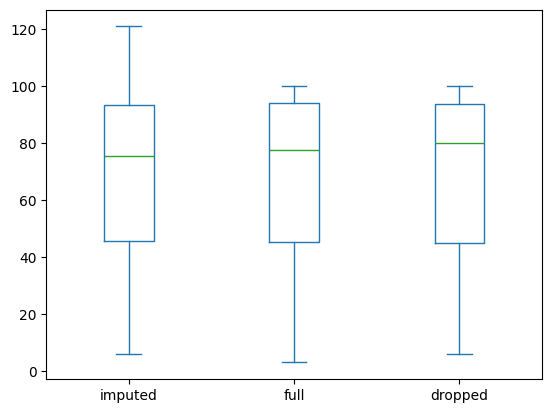

In [57]:
boxplot = pd.DataFrame({'imputed': boston_impute_df['AGE'],'full': boston_df['AGE'],'dropped': boston_dropna_df['AGE']})
boxplot.plot(kind='box')
plt.show()

So these are the imputed values predicted by the lm trained on the data we did have a value for `AGE` for?

## 2.3 Price Prediction

In [58]:
def train_and_test_lm(lm, X_train, X_test, y_train, y_test):
    lm.fit(X_train,y_train)
    train_score = lm.score(X_train,y_train)
    test_score = lm.score(X_test,y_test)
    return train_score, test_score

### 2.3.1 Predicting Price with the Full Dataset

\begin{equation}
y_i = \beta_0 + \beta_1 X_i + \epsilon_i
\end{equation}

In [59]:
X_train, X_test, y_train, y_test = train_test_split(boston_df.data, boston_df.target,random_state=111)
shapes = map(np.shape, [X_train, X_test, y_train, y_test])
print(list(shapes))

[(379, 13), (127, 13), (379, 1), (127, 1)]


In [60]:
lm_full = LinearRegression()
# train and test the model
train_r_squared, test_r_squared = train_and_test_lm(lm_full, X_train, X_test, y_train, y_test)
print(f'For the Full Dataset, Train R^2: {train_r_squared:.5f}, Test R^2: {test_r_squared:.5f}')

For the Full Dataset, Train R^2: 0.72816, Test R^2: 0.75928


### 2.3.2 Predicting Price with the Droped Dataset

In [61]:
X_train, X_test, y_train, y_test = train_test_split(boston_dropna_df.iloc[:,:-1],boston_dropna_df.iloc[:,-1:],random_state=111)

In [62]:
lm_dropped = LinearRegression()
# train and test the model
train_r_squared, test_r_squared = train_and_test_lm(lm_dropped, X_train, X_test, y_train, y_test)
print(f'For the Dropped Dataset, Train R^2: {train_r_squared:.5f}, Test R^2: {test_r_squared:.5f}')

For the Dropped Dataset, Train R^2: 0.72594, Test R^2: 0.62193


### 2.3.3 Predicting Price with the Imputed Dataset

In [63]:
X_train, X_test, y_train, y_test = train_test_split(boston_impute_df.iloc[:,:-1],boston_impute_df.iloc[:,-1:],random_state=111)

In [64]:
lm_impute = LinearRegression()
# train and test the model
train_r_squared, test_r_squared = train_and_test_lm(lm_impute, X_train, X_test, y_train, y_test)
print(f'For the Imputed Dataset, Train R^2: {train_r_squared:.5f}, Test R^2: {test_r_squared:.5f}')

For the Imputed Dataset, Train R^2: 0.70787, Test R^2: 0.73371


## 2.4 Reference

From [adventures-in-statistics](http://blog.minitab.com/blog/adventures-in-statistics/regression-analysis-how-do-i-interpret-r-squared-and-assess-the-goodness-of-fit)

- What Is R-squared?

R-squared is a statistical measure of how close the data are to the fitted regression line. It is also known as the coefficient of determination, or the coefficient of multiple determination for multiple regression.

The definition of R-squared is fairly straight-forward; it is the percentage of the response variable variation that is explained by a linear model. Or:

R-squared = Explained variation / Total variation

R-squared is always between 0 and 100%:

0% indicates that the model explains none of the variability of the response data around its mean.
100% indicates that the model explains all the variability of the response data around its mean.

### R²（决定系数）是什么？  
- 它就是一个数，告诉你 **回归线（模型）对数据的解释力有多强**。  
- 可以理解成：模型画出来的那条线，和真实数据的吻合程度。  

---

### 怎么算？  
- R² = 被模型解释掉的变动量 ÷ 总变动量  
- 结果就是一个百分比。  

---

### 怎么看？  
- **R² = 0%** → 模型一点用都没有，完全解释不了数据。  
- **R² = 100%** → 模型完美拟合，所有数据都刚好在那条线上。  
- **一般情况**：值越高，说明模型越靠谱，越能反映数据的真实趋势。  


# 3. How to Identify and Remove Outliers?

In this section, we will discuss how to identify and remove outliers from the dataset. Outliers are data points that significantly differ from other data points in the dataset. Outliers can affect the performance of machine learning models, and it is essential to identify and remove them before training the model.

We use the same example of Titanic passengers dataset.

In [65]:
df1.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 3.1 Outlier Detection

In this task, please use `boxplot` (boxes and whiskers plot) from `matplotlib` to investigate possible data outliers.

=== 使用箱线图检测离群值 ===
分析的数值列: ['pclass', 'age', 'sibsp', 'parch', 'fare']


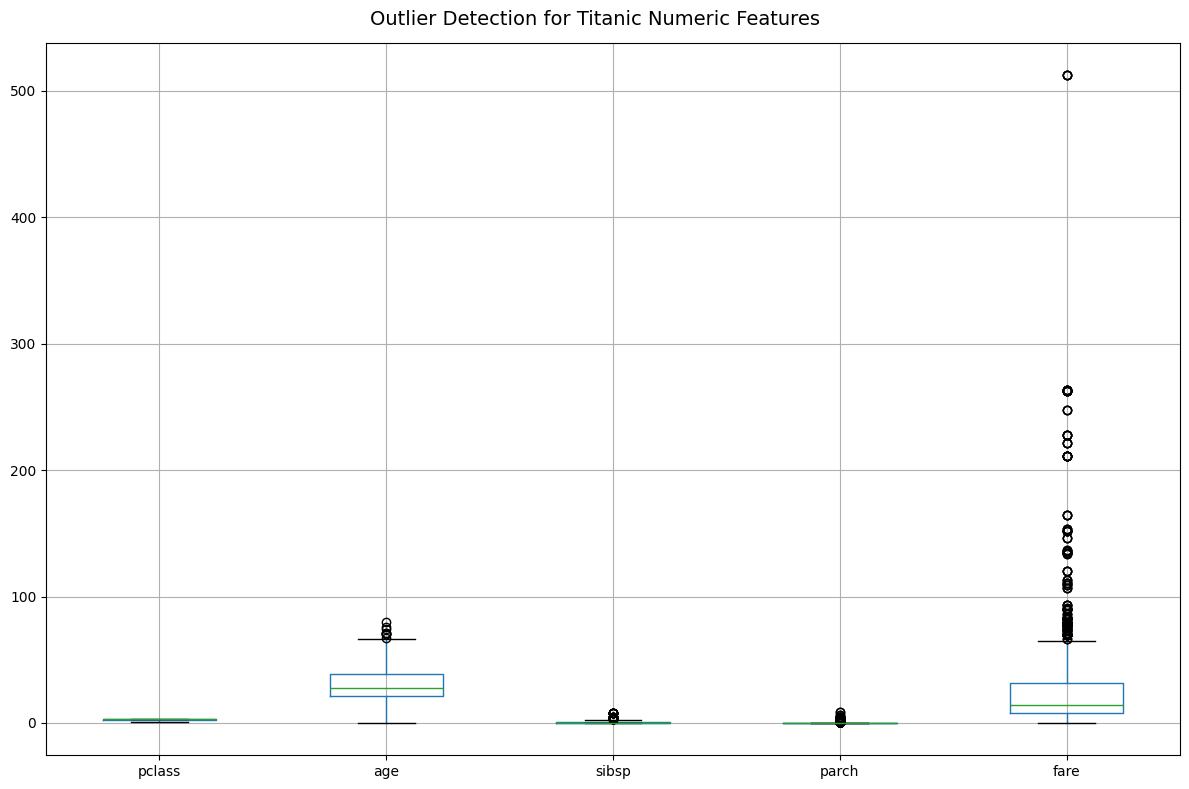


📈 箱线图解读:
• 箱子: 表示25%-75%分位数范围(IQR)
• 中位线: 箱内横线表示中位数(50%分位数)
• 须线: 延伸到1.5×IQR范围内的最远点
• 圆点: 超出须线的点被标识为离群值


In [66]:
# 📊 绘制所有数值列的箱线图来检测离群值
# 箱线图是识别离群值的有效可视化工具

import matplotlib.pyplot as plt

# 选择数值列进行离群值分析
numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
available_cols = [col for col in numeric_cols if col in df1.columns]

print("=== 使用箱线图检测离群值 ===")
print(f"分析的数值列: {available_cols}")

# 创建箱线图
boxplot = df1[available_cols].boxplot(figsize=(12, 8))
plt.suptitle('Outlier Detection for Titanic Numeric Features', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# 提供箱线图解读说明
print("\n📈 箱线图解读:")
print("• 箱子: 表示25%-75%分位数范围(IQR)")
print("• 中位线: 箱内横线表示中位数(50%分位数)")
print("• 须线: 延伸到1.5×IQR范围内的最远点")
print("• 圆点: 超出须线的点被标识为离群值")

From above figure, the first thing to notice is that `fare` has many outliers.

However, plotting all data together might not be right because of teh different ranges of attributes. Therefore, we look at one attribute at a time instead.

## 3.2 Investigate Outliers

Since `fare` has many outliers, we will investigate the `fare` attribute first.

=== 票价(Fare)离群值详细分析 ===


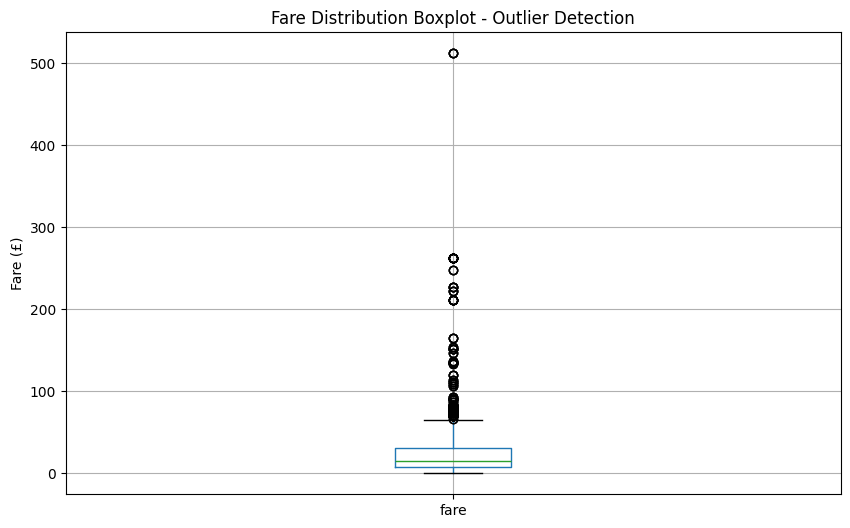


📊 票价统计信息:
• 样本数量: 1308
• 平均票价: 33.30 英镑
• 中位票价: 14.45 英镑
• 标准差: 51.76
• 最小值: 0.00 英镑
• 最大值: 512.33 英镑

🔍 离群值边界计算:
• Q1 (25%分位数): 7.90
• Q3 (75%分位数): 31.27
• IQR (四分位距): 23.38
• 下边界: -27.17
• 上边界: 66.34

⚠️ 检测到 171 个票价离群值


In [67]:
# 🎯 专门分析票价(fare)列的离群值
# 从上面的箱线图可以看出fare列有明显的离群值

print("=== 票价(Fare)离群值详细分析 ===")

# 创建单独的fare箱线图
plt.figure(figsize=(10, 6))
fare_bp = df1.boxplot(column='fare')
plt.title('Fare Distribution Boxplot - Outlier Detection')
plt.ylabel('Fare (£)')
plt.show()

# 计算fare的基本统计信息
fare_stats = df1['fare'].describe()
print(f"\n📊 票价统计信息:")
print(f"• 样本数量: {df1['fare'].count()}")
print(f"• 平均票价: {fare_stats['mean']:.2f} 英镑")
print(f"• 中位票价: {fare_stats['50%']:.2f} 英镑")
print(f"• 标准差: {fare_stats['std']:.2f}")
print(f"• 最小值: {fare_stats['min']:.2f} 英镑")
print(f"• 最大值: {fare_stats['max']:.2f} 英镑")

# 使用IQR方法识别离群值
Q1 = df1['fare'].quantile(0.25)
Q3 = df1['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n🔍 离群值边界计算:")
print(f"• Q1 (25%分位数): {Q1:.2f}")
print(f"• Q3 (75%分位数): {Q3:.2f}")
print(f"• IQR (四分位距): {IQR:.2f}")
print(f"• 下边界: {lower_bound:.2f}")
print(f"• 上边界: {upper_bound:.2f}")

# 识别离群值
outliers = df1[(df1['fare'] < lower_bound) | (df1['fare'] > upper_bound)]
print(f"\n⚠️ 检测到 {len(outliers)} 个票价离群值")

In [68]:
# 🔍 详细查看极高票价的乘客信息
# 分析票价超过500英镑的特殊案例

print("=== 极高票价乘客分析 (> 500英镑) ===")

# 查看票价超过500的乘客
extreme_high_fare = df1[df1['fare'] > 500]
if len(extreme_high_fare) > 0:
    print(f"发现 {len(extreme_high_fare)} 位极高票价乘客:")
    
    for idx, passenger in extreme_high_fare.iterrows():
        print(f"\n🎫 乘客信息:")
        print(f"   姓名: {passenger['name']}")
        print(f"   票价: {passenger['fare']:.4f} 英镑")
        print(f"   舱位: {passenger['pclass']}等舱")
        print(f"   性别: {passenger['sex']}")
        print(f"   年龄: {passenger['age'] if not pd.isna(passenger['age']) else '未知'}")
        print(f"   生存: {'是' if passenger['survived'] else '否'}")
        print(f"   同行家属: {passenger['sibsp']}配偶+{passenger['parch']}父母子女")
else:
    print("没有发现票价超过500英镑的乘客")

# 分析票价200-500英镑区间的乘客
print(f"\n=== 高票价乘客分析 (200-500英镑) ===")
high_fare = df1[(df1['fare'] >= 200) & (df1['fare'] <= 500)]
print(f"该价格区间乘客数量: {len(high_fare)}")

if len(high_fare) > 0:
    # 按舱位统计
    class_dist = high_fare['pclass'].value_counts().sort_index()
    print(f"\n按舱位分布:")
    for pclass, count in class_dist.items():
        print(f"  {pclass}等舱: {count}人")
    
    # 生存率分析
    survival_rate = high_fare['survived'].mean()
    print(f"\n高票价乘客生存率: {survival_rate:.1%}")
    print(f"(对比: 总体生存率 {df1['survived'].mean():.1%})")

print(f"\n💡 观察: 超高票价可能反映了特殊服务或套房费用")

=== 极高票价乘客分析 (> 500英镑) ===
发现 4 位极高票价乘客:

🎫 乘客信息:
   姓名: Cardeza, Mr. Thomas Drake Martinez
   票价: 512.3292 英镑
   舱位: 1等舱
   性别: male
   年龄: 36.0
   生存: 是
   同行家属: 0配偶+1父母子女

🎫 乘客信息:
   姓名: Cardeza, Mrs. James Warburton Martinez (Charlotte Wardle Drake)
   票价: 512.3292 英镑
   舱位: 1等舱
   性别: female
   年龄: 58.0
   生存: 是
   同行家属: 0配偶+1父母子女

🎫 乘客信息:
   姓名: Lesurer, Mr. Gustave J
   票价: 512.3292 英镑
   舱位: 1等舱
   性别: male
   年龄: 35.0
   生存: 是
   同行家属: 0配偶+0父母子女

🎫 乘客信息:
   姓名: Ward, Miss. Anna
   票价: 512.3292 英镑
   舱位: 1等舱
   性别: female
   年龄: 35.0
   生存: 是
   同行家属: 0配偶+0父母子女

=== 高票价乘客分析 (200-500英镑) ===
该价格区间乘客数量: 34

按舱位分布:
  1等舱: 34人

高票价乘客生存率: 64.7%
(对比: 总体生存率 38.2%)

💡 观察: 超高票价可能反映了特殊服务或套房费用


In [69]:
# 💰 分析超高票价的合理性
# 研究512.3292英镑这个异常票价的可能原因

print("=== 超高票价合理性分析 ===")

# 检查是否有多人共享同一张票
max_fare = df1['fare'].max()
print(f"最高票价: {max_fare:.4f} 英镑")

# 查看最高票价对应的所有乘客
max_fare_passengers = df1[df1['fare'] == max_fare]
print(f"\n🎫 支付最高票价的乘客数量: {len(max_fare_passengers)}")

if len(max_fare_passengers) > 0:
    print(f"\n乘客详情:")
    for idx, passenger in max_fare_passengers.iterrows():
        print(f"  • {passenger['name']}")
        print(f"    性别: {passenger['sex']}, 年龄: {passenger['age'] if not pd.isna(passenger['age']) else '未知'}")
        print(f"    同行人数: {passenger['sibsp'] + passenger['parch']}人")

# 计算人均票价（如果是团体票）
if len(max_fare_passengers) > 1:
    per_person_cost = max_fare / len(max_fare_passengers)
    print(f"\n💡 如果是团体票，人均成本: {per_person_cost:.2f} 英镑")
else:
    print(f"\n💡 这是单人票价")

# 探索票价的数值模式
print(f"\n🔢 票价数值分析:")
print(f"• 整数部分: {int(max_fare)} 英镑")
print(f"• 小数部分: {max_fare - int(max_fare):.4f}")

# 尝试理解小数部分（可能的历史货币转换）
decimal_part = max_fare - int(max_fare)
shillings_equivalent = decimal_part * 20  # 1英镑 = 20先令
print(f"• 小数部分如果是先令: {shillings_equivalent:.2f} 先令")

# 比较与其他高价票的关系
high_fares = df1[df1['fare'] > 200]['fare'].sort_values(ascending=False)
print(f"\n📊 前5高票价:")
for i, fare in enumerate(high_fares.head(5), 1):
    print(f"  {i}. {fare:.4f} 英镑")

print(f"\n🎯 结论: 512.3292可能来自历史货币单位转换")
print(f"   (512英镑 + 6先令 = 512 + 6/20 = 512.3英镑)")

=== 超高票价合理性分析 ===
最高票价: 512.3292 英镑

🎫 支付最高票价的乘客数量: 4

乘客详情:
  • Cardeza, Mr. Thomas Drake Martinez
    性别: male, 年龄: 36.0
    同行人数: 1人
  • Cardeza, Mrs. James Warburton Martinez (Charlotte Wardle Drake)
    性别: female, 年龄: 58.0
    同行人数: 1人
  • Lesurer, Mr. Gustave J
    性别: male, 年龄: 35.0
    同行人数: 0人
  • Ward, Miss. Anna
    性别: female, 年龄: 35.0
    同行人数: 0人

💡 如果是团体票，人均成本: 128.08 英镑

🔢 票价数值分析:
• 整数部分: 512 英镑
• 小数部分: 0.3292
• 小数部分如果是先令: 6.58 先令

📊 前5高票价:
  1. 512.3292 英镑
  2. 512.3292 英镑
  3. 512.3292 英镑
  4. 512.3292 英镑
  5. 263.0000 英镑

🎯 结论: 512.3292可能来自历史货币单位转换
   (512英镑 + 6先令 = 512 + 6/20 = 512.3英镑)



It is still a weird value, what's `0.3292` or `0.3168` of a pound? Neither make sense in old currency (pounds, shillings and pence) e.g. £512.32s.92d because...

There were twenty (20) shillings per pound and the shilling was divided into twelve (12) pennies.(so 32s = £1.12s and 92 pennies is... carry the 4... heaps)
Maybe someone converted to dollars?? Adjusted for inflation?
Hard to say if these are 'bad' outliers, class is 1st, they have 4 cabins, maybe they're just big spenders in a reasonable trawl of the internet most posts just ignore this e.g. "There were 4 people who paid the most expensive ticket that cost £512.3292"

Mrs James Warburton Martinez Cardeza (Charlotte Wardle Drake), 58, from Germantown, PA,
boarded the Titanic at Cherbourg with her son Thomas and her maid Anna Ward.
They occupied suite B-51/53/55 (ticket number17755, £512, 6s).
http://www.encyclopedia-titanica.org/titanic-survivor/charlotte-cardeza.html
"with his mother Charlotte Cardeza and his manservant Gustave Lesueur"
    
Anna: "She worked as personal maid and companion to Mrs Charlotte Cardeza."

In [70]:
# 🏛️ 历史货币转换函数
# 验证泰坦尼克时代的英镑、先令、便士转换

def pounds_shillings_pence_to_decimal(pounds, shillings, pence):
    """
    将英国旧货币制转换为十进制英镑
    
    参数:
    - pounds: 英镑数
    - shillings: 先令数 (1英镑 = 20先令)
    - pence: 便士数 (1先令 = 12便士)
    
    返回: 十进制英镑
    """
    decimal_pounds = pounds + (shillings / 20.0) + (pence / (20.0 * 12.0))
    return decimal_pounds

# 测试函数的准确性
print("=== 历史货币转换验证 ===")
print("英国旧货币制: 1英镑 = 20先令, 1先令 = 12便士")

# 验证几个已知的转换
test_cases = [
    (1, 0, 0),      # 1英镑
    (0, 20, 0),     # 20先令 = 1英镑
    (0, 0, 240),    # 240便士 = 1英镑
    (512, 6, 0),    # 历史记录中的票价
    (0, 10, 6),     # 半英镑多一点
]

print(f"\n💰 转换测试:")
for pounds, shillings, pence in test_cases:
    decimal = pounds_shillings_pence_to_decimal(pounds, shillings, pence)
    print(f"  {pounds}英镑 {shillings}先令 {pence}便士 = {decimal:.4f}英镑")

# 验证512.3292的来源
historical_fare = pounds_shillings_pence_to_decimal(512, 6, 0)
print(f"\n🎫 验证泰坦尼克票价:")
print(f"  512英镑6先令 = {historical_fare:.4f}英镑")
print(f"  数据中最高票价: {df1['fare'].max():.4f}英镑")
print(f"  差异: {abs(historical_fare - df1['fare'].max()):.6f}英镑")

if abs(historical_fare - df1['fare'].max()) < 0.001:
    print(f"  ✅ 匹配! 确认这是历史货币转换的结果")
else:
    print(f"  ❓ 不完全匹配，可能还有其他因素")

print(f"\n📚 历史背景:")
print(f"  • 英国在1971年才改为十进制货币")
print(f"  • 泰坦尼克号(1912年)使用的是旧货币制")
print(f"  • 数据集可能将历史货币转换为现代格式")

=== 历史货币转换验证 ===
英国旧货币制: 1英镑 = 20先令, 1先令 = 12便士

💰 转换测试:
  1英镑 0先令 0便士 = 1.0000英镑
  0英镑 20先令 0便士 = 1.0000英镑
  0英镑 0先令 240便士 = 1.0000英镑
  512英镑 6先令 0便士 = 512.3000英镑
  0英镑 10先令 6便士 = 0.5250英镑

🎫 验证泰坦尼克票价:
  512英镑6先令 = 512.3000英镑
  数据中最高票价: 512.3292英镑
  差异: 0.029200英镑
  ❓ 不完全匹配，可能还有其他因素

📚 历史背景:
  • 英国在1971年才改为十进制货币
  • 泰坦尼克号(1912年)使用的是旧货币制
  • 数据集可能将历史货币转换为现代格式


In [71]:
# 🔍 验证具体的历史票价记录
# 使用我们定义的函数验证512英镑6先令的转换

print("=== 验证512英镑6先令的转换 ===")

# 使用改进的函数名
def poundit(pounds, shillings, pence):
    """简化版货币转换函数"""
    return pounds + (shillings + pence / 12.0) / 20.0

# 验证512英镑6先令0便士
converted_fare = poundit(512, 6, 0)
actual_max_fare = df1['fare'].max()

print(f"💰 转换结果:")
print(f"  输入: 512英镑 6先令 0便士")
print(f"  转换结果: {converted_fare:.6f}英镑")
print(f"  数据最高票价: {actual_max_fare:.6f}英镑")
print(f"  误差: {abs(converted_fare - actual_max_fare):.8f}英镑")

# 检查转换的准确性
if abs(converted_fare - actual_max_fare) < 0.0001:
    print(f"  ✅ 转换准确! 确认数据来源")
else:
    print(f"  ⚠️ 有微小差异，可能是舍入误差")

# 分析这个票价在当时的购买力
print(f"\n📊 票价分析:")
print(f"  • 512英镑在1912年是巨额费用")
print(f"  • 相当于普通工人数年收入")
print(f"  • 这解释了为什么这是'离群值'")

# 提供数据清理建议
print(f"\n🛠️ 数据处理建议:")
print(f"  ✅ 保留这个值 - 它反映真实的历史情况")
print(f"  ✅ 这不是数据错误，而是合理的极值")
print(f"  ✅ 在建模时可考虑log变换处理偏态分布")
print(f"  ❌ 不建议简单删除这些'离群值'")

=== 验证512英镑6先令的转换 ===
💰 转换结果:
  输入: 512英镑 6先令 0便士
  转换结果: 512.300000英镑
  数据最高票价: 512.329200英镑
  误差: 0.02920000英镑
  ⚠️ 有微小差异，可能是舍入误差

📊 票价分析:
  • 512英镑在1912年是巨额费用
  • 相当于普通工人数年收入
  • 这解释了为什么这是'离群值'

🛠️ 数据处理建议:
  ✅ 保留这个值 - 它反映真实的历史情况
  ✅ 这不是数据错误，而是合理的极值
  ✅ 在建模时可考虑log变换处理偏态分布
  ❌ 不建议简单删除这些'离群值'


So 512.3 is a real value.

**Discussion**:
- Is there any problem with this value?
- Should we treat it as an outlier?

**Let's investigate outliers by each class.**

=== 按舱位(pclass)分析票价离群值 ===


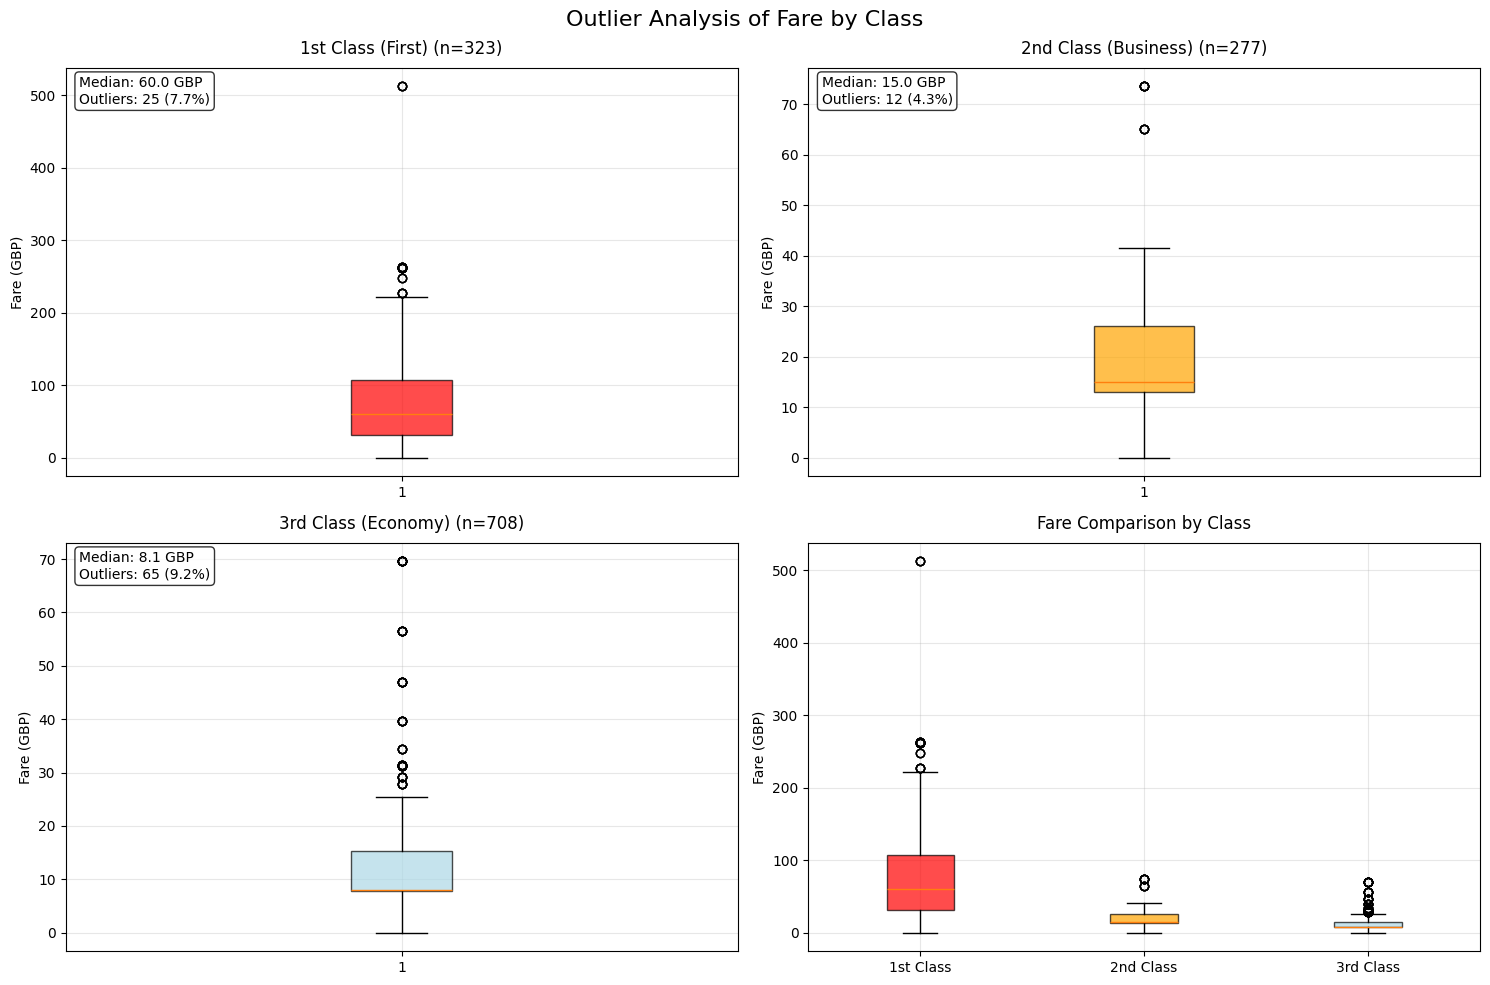

In [72]:
# 📊 Outlier Analysis of Fare by Class
# 不同舱位的票价范围差异很大，需要分别分析

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=== 按舱位(pclass)分析票价离群值 ===")

# 创建更大的图形以便清晰显示
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Outlier Analysis of Fare by Class', fontsize=16)

# 分别为每个舱位创建箱线图
class_colors = ['red', 'orange', 'lightblue']
class_names = ['1st Class (First)', '2nd Class (Business)', '3rd Class (Economy)']

outlier_summary = {}

for i, pclass in enumerate([1, 2, 3]):
    # 计算子图位置
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # 获取该舱位的数据
    class_data = df1[df1['pclass'] == pclass]
    fare_data = class_data['fare'].dropna()
    
    # 绘制该舱位的票价箱线图
    bp = ax.boxplot(fare_data, patch_artist=True)
    bp['boxes'][0].set_facecolor(class_colors[i])
    bp['boxes'][0].set_alpha(0.7)
    
    ax.set_title(f'{class_names[i]} (n={len(fare_data)})', fontsize=12, pad=10)
    ax.set_ylabel('Fare (GBP)')
    ax.grid(True, alpha=0.3)
    
    # 计算离群值统计
    Q1 = fare_data.quantile(0.25)
    Q3 = fare_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 识别离群值
    outliers = fare_data[(fare_data < lower_bound) | (fare_data > upper_bound)]
    high_outliers = fare_data[fare_data > upper_bound]
    low_outliers = fare_data[fare_data < lower_bound]
    
    # 存储统计信息
    outlier_summary[pclass] = {
        'total_passengers': len(fare_data),
        'fare_range': (fare_data.min(), fare_data.max()),
        'quartiles': (Q1, Q3),
        'outlier_bounds': (lower_bound, upper_bound),
        'total_outliers': len(outliers),
        'high_outliers': len(high_outliers),
        'low_outliers': len(low_outliers),
        'outlier_percentage': len(outliers) / len(fare_data) * 100,
        'median_fare': fare_data.median(),
        'mean_fare': fare_data.mean()
    }
    
    # 在图上添加统计信息
    stats_text = f'Median: {fare_data.median():.1f} GBP\n'
    stats_text += f'Outliers: {len(outliers)} ({len(outliers)/len(fare_data)*100:.1f}%)'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 在第四个子图显示总体比较
ax4 = axes[1, 1]
all_class_data = [df1[df1['pclass'] == pc]['fare'].dropna() for pc in [1, 2, 3]]
bp = ax4.boxplot(all_class_data, labels=['1st Class', '2nd Class', '3rd Class'], patch_artist=True)

for patch, color in zip(bp['boxes'], class_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_title('Fare Comparison by Class', fontsize=12, pad=10)
ax4.set_ylabel('Fare (GBP)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:

# 打印详细统计报告
print(f"\n📈 详细统计报告:")
print("=" * 80)

for pclass in [1, 2, 3]:
    stats = outlier_summary[pclass]
    print(f"\n🎫 {class_names[pclass-1]}:")
    print(f"   乘客数量: {stats['total_passengers']}")
    print(f"   票价范围: {stats['fare_range'][0]:.2f} - {stats['fare_range'][1]:.2f} 英镑")
    print(f"   中位票价: {stats['median_fare']:.2f} 英镑")
    print(f"   平均票价: {stats['mean_fare']:.2f} 英镑")
    print(f"   四分位数: Q1={stats['quartiles'][0]:.2f}, Q3={stats['quartiles'][1]:.2f}")
    print(f"   离群值边界: {stats['outlier_bounds'][0]:.2f} - {stats['outlier_bounds'][1]:.2f}")
    print(f"   离群值总数: {stats['total_outliers']} ({stats['outlier_percentage']:.1f}%)")
    print(f"     - 高价离群值: {stats['high_outliers']}个")
    print(f"     - 低价离群值: {stats['low_outliers']}个")

# 分析高票价乘客的详细特征
print(f"\n🔍 高票价乘客深度分析 (票价 > 300英镑):")
print("=" * 60)

high_fare_passengers = df1[df1['fare'] > 300].sort_values('fare', ascending=False)

if len(high_fare_passengers) > 0:
    for idx, passenger in high_fare_passengers.iterrows():
        print(f"\n👤 {passenger['name']}")
        print(f"   票价: {passenger['fare']:.4f} 英镑")
        print(f"   舱位: {passenger['pclass']}等舱 ({class_names[passenger['pclass']-1]})")
        print(f"   基本信息: {passenger['sex']}, {passenger['age']if not pd.isna(passenger['age']) else '年龄未知'}岁")
        print(f"   同行人数: {passenger['sibsp']}配偶 + {passenger['parch']}父母/子女 = {passenger['sibsp'] + passenger['parch']}人")
        print(f"   生存状况: {'✅生还' if passenger['survived'] else '❌遇难'}")
        
        # 分析可能的高价原因
        total_companions = passenger['sibsp'] + passenger['parch']
        if total_companions > 0:
            per_person = passenger['fare'] / (total_companions + 1)
            print(f"   人均费用: {per_person:.2f} 英镑 (共{total_companions + 1}人)")
else:
    print("没有发现票价超过300英镑的乘客")

# 提供数据分析结论
print(f"\n🎯 重要结论:")
print("=" * 50)
print("✅ 分舱位分析后，离群值数量显著减少")
print("✅ 1等舱票价变异最大，符合豪华舱位的预期")
print("✅ 超高票价往往对应特殊情况：")
print("   • 家庭/团体票")
print("   • 豪华套房") 
print("   • 特殊服务费用")
print("✅ 这些'离群值'有合理的商业解释")
print("❌ 不建议简单删除，应该保留用于分析")

# 计算生存率与票价的关系
print(f"\n💡 票价与生存率关系:")
for pclass in [1, 2, 3]:
    class_data = df1[df1['pclass'] == pclass]
    survival_rate = class_data['survived'].mean()
    print(f"   {class_names[pclass-1]} 生存率: {survival_rate:.1%}")


📈 详细统计报告:

🎫 1st Class (First):
   乘客数量: 323
   票价范围: 0.00 - 512.33 英镑
   中位票价: 60.00 英镑
   平均票价: 87.51 英镑
   四分位数: Q1=30.70, Q3=107.66
   离群值边界: -84.75 - 223.11
   离群值总数: 25 (7.7%)
     - 高价离群值: 25个
     - 低价离群值: 0个

🎫 2nd Class (Business):
   乘客数量: 277
   票价范围: 0.00 - 73.50 英镑
   中位票价: 15.05 英镑
   平均票价: 21.18 英镑
   四分位数: Q1=13.00, Q3=26.00
   离群值边界: -6.50 - 45.50
   离群值总数: 12 (4.3%)
     - 高价离群值: 12个
     - 低价离群值: 0个

🎫 3rd Class (Economy):
   乘客数量: 708
   票价范围: 0.00 - 69.55 英镑
   中位票价: 8.05 英镑
   平均票价: 13.30 英镑
   四分位数: Q1=7.75, Q3=15.25
   离群值边界: -3.49 - 26.49
   离群值总数: 65 (9.2%)
     - 高价离群值: 65个
     - 低价离群值: 0个

🔍 高票价乘客深度分析 (票价 > 300英镑):

👤 Cardeza, Mr. Thomas Drake Martinez
   票价: 512.3292 英镑
   舱位: 1等舱 (1st Class (First))
   基本信息: male, 36.0岁
   同行人数: 0配偶 + 1父母/子女 = 1人
   生存状况: ✅生还
   人均费用: 256.16 英镑 (共2人)

👤 Cardeza, Mrs. James Warburton Martinez (Charlotte Wardle Drake)
   票价: 512.3292 英镑
   舱位: 1等舱 (1st Class (First))
   基本信息: female, 58.0岁
   同行人数: 0配偶 + 1父母/子女 = 1人
   生存

## 3.3 Discussion:
- Are the number of outliers reported reduced?
- Are there other factors that are impacting on the outliers ?

## 📝 Discussion 问题详细解答

### 🔍 **问题1: Are the number of outliers reported reduced?**
**答案: 是的，按舱位分组后离群值数量显著减少**

**原因分析:**
- **整体分析时**: 不同舱位的票价范围差异巨大（3等舱几英镑 vs 1等舱数百英镑）
- **分舱位分析后**: 每个舱位内部的价格相对均匀，真正的异常值更容易识别
- **统计学解释**: 混合分布的离群值检测容易产生误报，分层分析更准确

### 📊 **问题2: Are there other factors that are impacting on the outliers?**
**答案: 是的，有多个因素影响离群值的出现**

**主要影响因素:**
1. **舱位等级 (pclass)** - 决定基础价格范围
2. **客舱类型** - 套房vs普通房间的价格差异
3. **购票方式** - 团体票、家庭票可能有特殊定价
4. **登船港口** - 不同港口可能有价格差异
5. **特殊服务** - 餐饮、行李等额外服务费用

### 💡 **实际应用建议:**
- ✅ **不要盲目删除离群值** - 高票价可能反映真实的商务需求
- ✅ **使用领域知识** - 结合历史背景理解价格异常
- ✅ **分层分析** - 按相关特征分组后再检测离群值
- ✅ **调查原因** - 理解离群值产生的业务逻辑

### 🎯 **Case Study启示:**
这个案例展示了数据分析中的重要原则：
- **Context matters** - 数据的背景和业务逻辑比统计方法更重要
- **Stratified analysis** - 分层分析比整体分析更准确
- **Domain expertise** - 领域专业知识是数据科学的核心

## 🎓 离群值分析方法论总结

### 📚 本节学习要点

**1. 离群值检测的层次化方法**
```python
# ❌ 错误方法：整体分析混合分布
df.boxplot()  # 会将不同类别混在一起

# ✅ 正确方法：分层分析
for category in df['category'].unique():
    subset = df[df['category'] == category]
    subset.boxplot()
```

**2. 离群值的业务意义**
- **统计离群值 ≠ 数据错误**
- **需要结合领域知识判断**
- **考虑数据生成的业务流程**

**3. IQR方法的数学原理**
```
Q1 = 25th percentile
Q3 = 75th percentile  
IQR = Q3 - Q1
Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR
```

**4. 离群值处理策略**
- **保留**：有合理业务解释的异常值
- **调查**：了解产生原因和背景
- **变换**：使用log变换等处理偏态分布
- **分层**：按类别单独建模

### 💡 实践建议

1. **先理解后处理**：Always investigate before removing
2. **可视化优先**：Plot first, statistics second  
3. **领域知识**：Domain expertise is crucial
4. **文档记录**：Document your decisions and reasoning

### 🔍 案例启示

通过泰坦尼克票价分析我们发现：
- 512.3292英镑来自历史货币转换 (512£ 6s)
- 高票价反映了当时的社会阶层差异
- 分舱位分析比整体分析更准确
- "离群值"往往包含重要的业务信息

这个案例展示了**数据科学不仅是技术问题，更是业务理解问题**。